# Objective

This notebook computes the missing metrics identified in the `seleccion_modelos_v2` review:

1. **ICI at 6 and 12 months** (currently only ICI60 is available in existing notebooks)
2. **Dual metrics** for pending models (`formula_readmit`, `formula_readmit_updated`, `formula_death`, `formula_death_updated`, `formula_shap_death_interact`)
3. **DCA** (Decision Curve Analysis) for the primary models
4. **Consolidated table** with all metrics from all candidate models

It does not re-evaluate models that already have metrics computed in `prediction22` or `prediction24`; it only fills in the missing cells.

## 1. Setup: loading environment, functions, and data

In [1]:
#setwd("g:/My Drive/Alvacast/SISTRAT 2023/")

In [2]:
#| label: setup
#| message: false

# --- Identify project root ---
if (interactive()) {
  cwd <- getwd()
} else {
  cwd <- getwd()
}

project_root <- tryCatch({
  if (grepl("/cons$", cwd)) {
    dirname(cwd)

  } else if (grepl("\\\\cons$", cwd)) {
    dirname(cwd)
  } else if (file.exists(file.path(cwd, "cons"))) {
    cwd
  } else {
    # Search recursively
    candidate <- list.files(
      cwd,
      pattern = "pred2._ndp_.*\\.Rdata$",
      recursive = TRUE,
      full.names = TRUE
    )
    if (length(candidate) > 0) {
      dirname(dirname(candidate[1]))
    } else {
      cwd
    }
  }
}, error = function(e) cwd)

cat("Project root:", project_root, "\n")
setwd(project_root)

# Explicitly activate the main project renv (Jupyter kernels in cons/ may load cons/renv otherwise)
source(file.path(project_root, "renv", "activate.R"))

Project root: g:/My Drive/Alvacast/SISTRAT 2023 
- Project 'G:/My Drive/Alvacast/SISTRAT 2023' loaded. [renv 1.2.3]
The following package(s) are missing their DESCRIPTION files:
- desktop.ini [G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32/desktop.ini]
These may be left over from a prior, failed installation attempt.
Consider removing or reinstalling these packages.

- The project is out-of-sync -- use `renv::status()` for details.


In [3]:
#| label: load-data
#| message: false

# --- Load the most recent prediction22 .Rdata (contains py_corrected_datasets, formulas, functions) ---
rdata_files <- list.files(
  file.path(project_root, "data", "20241015_out"),
  pattern = "pred22_ndp_.*\\.Rdata$",
  full.names = TRUE
)

if (length(rdata_files) == 0) {
  # Fallback to prediction22 file
  rdata_files <- list.files(
    project_root,
    pattern = "pred22_ndp_2026_06_17\\.Rdata$",
    recursive = TRUE,
    full.names = TRUE
  )
}

if (length(rdata_files) > 0) {
  load(rdata_files[length(rdata_files)])
  cat("Loaded file:", rdata_files[length(rdata_files)], "\n")
} else {
  stop("No .Rdata file found. Adjust the path manually.")
}

# Verify essential objects
stopifnot(exists("py_corrected_datasets"))
stopifnot(exists("formula_death_updated2"))
cat("py_corrected_datasets:", length(py_corrected_datasets_boot), "imputations\n")
cat("rows per imputation:", nrow(py_corrected_datasets_boot[[1]]), "\n")

Loaded file: g:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/pred22_ndp_2026_06_18.Rdata 
py_corrected_datasets: 5 imputations
rows per imputation: 70521 


In [4]:
#| label: define-formulas
#| message: false

# --- Check which formulas are available in the environment ---
formula_names <- c(
  "formula_readmit", "formula_readmit_updated", "formula_readmit_updated2",
  "formula_death", "formula_death_updated", "formula_death_updated2",
  "formula_shap_readmit_clean", "formula_shap_readmit_clean_updated",
  "formula_shap_death_rule2",
  "formula_shap_readmit_interact", "formula_shap_death_interact"
)

for (fn in formula_names) {
  if (exists(fn)) {
    f <- get(fn)
    if (inherits(f, "formula")) {
      cat(sprintf("  [OK] %s\n", fn))
    } else {
      cat(sprintf("  [WARN] %s exists but is not a formula\n", fn))
    }
  } else {
    cat(sprintf("  [MISS] %s NOT in environment\n", fn))
  }
}

# For missing ones, define them from the prediction22 notebook
if (!exists("formula_readmit")) {
  warning("formula_readmit not available. Check the .Rdata file.")
}
if (!exists("formula_death")) {
  warning("formula_death not available. Check the .Rdata file.")
}

  [OK] formula_readmit
  [OK] formula_readmit_updated
  [OK] formula_readmit_updated2
  [OK] formula_death
  [OK] formula_death_updated
  [OK] formula_death_updated2
  [OK] formula_shap_readmit_clean
  [OK] formula_shap_readmit_clean_updated
  [OK] formula_shap_death_rule2
  [OK] formula_shap_readmit_interact
  [OK] formula_shap_death_interact


In [5]:
#| label: load-libraries
#| message: false

# --- Configure parallel plan ---
library(future)
library(future.apply)
library(survival)
library(ggplot2)
library(readr)
library(tableone)
library(survivalmodels)
#renv::install("patchwork@1.2.0")
library(rms)
library(survidm)
library(caret)
library(survival)
library(caret)
library(dplyr)
library(survex)
library(pec)
library(parallel)
library(mice)
library(riskRegression)
library(tidyr)
library(doFuture)
library(vcd)
library(survAUC)

gc()


Attaching package: ‘survival’

The following object is masked from ‘package:future’:

    cluster

Loading required package: Hmisc

Attaching package: ‘Hmisc’

The following objects are masked from ‘package:base’:

    format.pval, units



Warning message:
package ‘Hmisc’ was built under R version 4.4.3 


Loading required package: lattice

Attaching package: ‘caret’

The following object is masked from ‘package:survival’:

    cluster

The following object is masked from ‘package:future’:

    cluster


Attaching package: ‘dplyr’

The following objects are masked from ‘package:Hmisc’:

    src, summarize

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Attaching package: ‘survex’

The following object is masked from ‘package:dplyr’:

    explain

Loading required package: prodlim

Attaching package: ‘pec’

The following object is masked from ‘package:caret’:

    R2

The following object is masked from ‘package:survivalmodels’:

    cindex



Warning message:
package ‘prodlim’ was built under R version 4.4.3 



Attaching package: ‘mice’

The following object is masked from ‘package:stats’:

    filter

The following objects are masked from ‘package:base’:

    cbind, rbind

Registered S3 method overwritten by 'riskRegression':
  method        from 
  nobs.multinom broom
riskRegression version 2026.02.13

Attaching package: ‘riskRegression’

The following objects are masked from ‘package:pec’:

    ipcw, selectCox

Loading required package: foreach
Loading required package: grid


             used    (Mb) gc trigger    (Mb)   max used    (Mb)
Ncells    9991019   533.6   14579602   778.7   14579602   778.7
Vcells 2513046611 19173.1 3461559191 26409.7 2519712687 19223.9

In [6]:
#| label: source-functions
#| message: false

# --- Source required functions (if not already in the environment) ---

# The actual calibration function is called calibrate_cscox_aj_grouped_corr
# (NOT calibrate_cph_grouped_corr)
source("cons/_alt_scripts/calibrate_cscox_aj_grouped_corr.R")
cat("Sourced: calibrate_cscox_aj_grouped_corr\n")

source("cons/_alt_scripts/evaluate_dual_cox_python_style_boot.R")
cat("Sourced: evaluate_dual_cox_python_style\n")

# Verify essential functions
stopifnot(exists("calibrate_cscox_aj_grouped_corr"))
stopifnot(exists("evaluate_dual_cox_python_style"))
cat("Functions ready.\n")

Sourced: calibrate_cscox_aj_grouped_corr
Sourced: evaluate_dual_cox_python_style
Functions ready.


In [7]:
#| label: deltaCIBS-cv-engine
#| message: false

# --- fallbacks (idénticos al pipeline; se saltan si ya existen) ---
if (!exists(".dual_cox_safe_concordance")) .dual_cox_safe_concordance <- function(time,event,lp,ymax=NULL){
  ok<-is.finite(time)&is.finite(event)&is.finite(lp); if(sum(ok)<2L) return(NA_real_)
  a<-list(survival::Surv(time[ok],event[ok])~lp[ok],timewt="n/G2",reverse=TRUE); if(!is.null(ymax)) a$ymax<-ymax
  tryCatch(do.call(survival::concordance,a)$concordance,error=function(e) NA_real_) }
if (!exists(".ibs_prep")) .ibs_prep <- function(tr_time,tr_event,te_time,eval_times,g_min=.05,eps=1e-8){
  ev<-as.numeric(tr_event); ev[is.na(ev)]<-0; sf<-survival::survfit(survival::Surv(tr_time,1-ev)~1)
  safe<-sf$time[sf$surv>=g_min]; tau<-if(length(safe)) max(safe) else max(eval_times)
  keep<-eval_times<=tau & eval_times<=max(tr_time,na.rm=TRUE); tu<-eval_times[keep]
  Gat<-function(tt) pmax(summary(sf,times=pmax(tt,0),extend=TRUE)$surv,g_min)
  list(times_use=tu,keep=keep,gt0=if(length(tu)) 1/Gat(tu) else numeric(0),gT=1/Gat(pmax(te_time-eps,0))) }
if (!exists("ibs_fast")) ibs_fast <- function(S_keep,te_time,te_event,idx,prep){
  tu<-prep$times_use; if(length(tu)<2L) return(NA_real_)
  Tt<-te_time[idx]; Dt<-te_event[idx]; gT<-prep$gT[idx]; S<-S_keep[idx,,drop=FALSE]
  bs<-vapply(seq_along(tu),function(j){t0<-tu[j];S0<-S[,j];ar<-Tt>t0;fl<-(!ar)&(Dt==1)
    w<-numeric(length(Tt)); w[ar]<-prep$gt0[j]*(1-S0[ar])^2; w[fl]<-gT[fl]*(S0[fl])^2; mean(w,na.rm=TRUE)},numeric(1))
  den<-max(tu)-min(tu); if(!is.finite(den)||den<=0) return(NA_real_)
  sum(diff(tu)*(head(bs,-1L)+tail(bs,-1L))/2)/den }

# --- reassemble OOF across folds -> per-subject, pooled over imputations ---
.cv_extract <- function(res, outcome = c("readmission","death")) {
  outcome <- match.arg(outcome)
  rp <- res$raw_predictions
  if (is.null(rp) || !length(rp)) stop("no raw_predictions (objeto strippeado o calibracion, no dual eval)")
  cfg <- res$config; et <- as.numeric(cfg$eval_times)
  N <- max(vapply(rp, function(b) max(b$original_val_idx), 1L))
  imps <- sort(unique(vapply(rp, function(b) b$imp_idx, 1L)))
  time_v <- rep(NA_real_,N); event_v <- rep(NA_real_,N); lp_imp <- list(); S_imp <- list()
  for (im in imps) {
    lp <- rep(NA_real_,N); S <- matrix(NA_real_,N,length(et))
    for (b in rp) { if (b$imp_idx!=im) next
      o <- b[[outcome]]; if (is.null(o)||!is.null(o$error)||is.null(o$lp_val)) next
      idx <- b$original_val_idx; lp[idx] <- as.numeric(o$lp_val); S[idx,] <- as.matrix(o$surv_val_matrix)
      yv <- o$y_val; time_v[idx] <- as.numeric(yv[,1]); event_v[idx] <- as.numeric(yv[,2]) }
    lp_imp[[length(lp_imp)+1L]] <- lp; S_imp[[length(S_imp)+1L]] <- S }
  list(time=time_v, event=event_v, lp=Reduce(`+`,lp_imp)/length(lp_imp),
       S=Reduce(`+`,S_imp)/length(S_imp), eval_times=et)
}

# --- paired bootstrap on already-extracted markers (align A,Z on common finite subjects) ---
deltaC_boot_x <- function(A, Z, B=2000L, seed=2125L, ymax=NULL) {
  ok <- is.finite(A$lp)&is.finite(Z$lp)&is.finite(A$time)&is.finite(A$event)
  ti<-A$time[ok]; ev<-A$event[ok]; la<-A$lp[ok]; lz<-Z$lp[ok]; n<-sum(ok); i0<-seq_len(n)
  cc <- function(m,idx) .dual_cox_safe_concordance(ti[idx],ev[idx],m[idx],ymax)
  cA<-cc(la,i0); cZ<-cc(lz,i0); set.seed(seed); d<-numeric(B)
  for (b in seq_len(B)) { idx<-sample.int(n,n,TRUE); d[b]<-cc(la,idx)-cc(lz,idx) }
  q<-quantile(d,c(.025,.975),na.rm=TRUE,names=FALSE)
  data.frame(C_A=round(cA,4),C_B=round(cZ,4),dC=round(cA-cZ,4),
             dC_lo=round(q[1],4),dC_hi=round(q[2],4),excludes_0=isTRUE(q[1]>0||q[2]<0),n=n) }
deltaIBS_boot_x <- function(A, Z, B=2000L, seed=2125L) {
  ok <- is.finite(A$lp)&is.finite(Z$lp)&is.finite(A$time)&is.finite(A$event) &
        rowSums(is.finite(A$S))==ncol(A$S) & rowSums(is.finite(Z$S))==ncol(Z$S)
  ti<-A$time[ok]; ev<-A$event[ok]; SA<-A$S[ok,,drop=FALSE]; SZ<-Z$S[ok,,drop=FALSE]
  prep<-.ibs_prep(ti,ev,ti,A$eval_times)                 # G del censurado de la cohorte OOF
  SAk<-SA[,prep$keep,drop=FALSE]; SZk<-SZ[,prep$keep,drop=FALSE]; n<-nrow(SAk); i0<-seq_len(n)
  iA<-ibs_fast(SAk,ti,ev,i0,prep); iZ<-ibs_fast(SZk,ti,ev,i0,prep); set.seed(seed); d<-numeric(B)
  for (b in seq_len(B)) { idx<-sample.int(n,n,TRUE); d[b]<-ibs_fast(SAk,ti,ev,idx,prep)-ibs_fast(SZk,ti,ev,idx,prep) }
  q<-quantile(d,c(.025,.975),na.rm=TRUE,names=FALSE)
  data.frame(IBS_A=round(iA,4),IBS_B=round(iZ,4),dIBS=round(iA-iZ,4),
             dIBS_lo=round(q[1],4),dIBS_hi=round(q[2],4),excludes_0=isTRUE(q[1]>0||q[2]<0),n=n) }


### Within stratum IBS/

In [8]:
# label: run-evaluation2-fullph

# risk_absolute (stratum-correct, coherent with IBS/calibration/DCA)
# within_stratum (sensitivity; may be NA/low-n for death)
options(dualcox.concordance_score = "lp", dualcox.concordance_within_strata = TRUE)
# options(dualcox.concordance_score = "risk", dualcox.concordance_within_strata = FALSE)

results_py_within <- evaluate_dual_cox_python_style(
  formula_readmit = formula_readmit,
  formula_death = formula_death,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 12, 36, 60)
)
results_py_within$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.1519546| 0.0090324| 0.1370399| 0.1660083| 25|
|Readmission |IBS           |12     | 0.2003691| 0.0092666| 0.1837207| 0.2136722| 25|
|Readmission |IBS           |36     | 0.2854153| 0.0087212| 0.2662975| 0.2976582| 25|
|Readmission |IBS           |60     | 0.3253073| 0.0081568| 0.3071592| 0.3356542| 25|
|Readmission |IBS           |Global | 0.3253073| 0.0081568| 0.3071592| 0.3356542| 25|
|Readmission |Uno's C-Index |6      | 0.5870664| 0.0089748| 0.5715748| 0.6030424| 25|
|Readmission |Uno's C-Index |12     | 0.5870311| 0.0050809| 0.5793219| 0.5962891| 25|
|Readmission |Uno's C-Index |36     | 0.5861983| 0.0049969| 0.5763843| 0.5946288| 25|
|Readmission |Uno's C-Index |60     | 0.5859259| 0.0056673| 0.5770751| 0.5973587| 25|
|Readmission 

In [9]:
# label: run-evaluation2-fullph-discarding-collinearity

results_upd_py_within <- evaluate_dual_cox_python_style(
  formula_readmit = formula_readmit_updated,
  formula_death = formula_death_updated,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 12, 36, 60)
)
results_upd_py_within$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary (discarded collinearity)")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary (discarded collinearity)

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.1519521| 0.0090317| 0.1370376| 0.1660101| 25|
|Readmission |IBS           |12     | 0.2003654| 0.0092655| 0.1837179| 0.2136667| 25|
|Readmission |IBS           |36     | 0.2854071| 0.0087159| 0.2662987| 0.2976492| 25|
|Readmission |IBS           |60     | 0.3252959| 0.0081484| 0.3071633| 0.3356612| 25|
|Readmission |IBS           |Global | 0.3252959| 0.0081484| 0.3071633| 0.3356612| 25|
|Readmission |Uno's C-Index |6      | 0.5871507| 0.0090369| 0.5715813| 0.6033831| 25|
|Readmission |Uno's C-Index |12     | 0.5871302| 0.0050825| 0.5795652| 0.5966005| 25|
|Readmission |Uno's C-Index |36     | 0.5863002| 0.0050553| 0.5764033| 0.5949980| 25|
|Readmission |Uno's C-Index |60     | 0.5860005| 0.0057316| 0.5770670| 0.5

In [10]:
# label: run-evaluation2-fullph-with-additional-strata

results_upd2_py_within <- evaluate_dual_cox_python_style(
  formula_readmit = formula_readmit_updated2,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 12, 36, 60)
)

results_upd2_py_within$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, updated predictors (+ strata)")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, updated predictors (+ strata)

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.1519521| 0.0090317| 0.1370376| 0.1660101| 25|
|Readmission |IBS           |12     | 0.2003654| 0.0092655| 0.1837179| 0.2136667| 25|
|Readmission |IBS           |36     | 0.2854071| 0.0087159| 0.2662987| 0.2976492| 25|
|Readmission |IBS           |60     | 0.3252959| 0.0081484| 0.3071633| 0.3356612| 25|
|Readmission |IBS           |Global | 0.3252959| 0.0081484| 0.3071633| 0.3356612| 25|
|Readmission |Uno's C-Index |6      | 0.5831879| 0.0092224| 0.5674814| 0.5984958| 25|
|Readmission |Uno's C-Index |12     | 0.5843862| 0.0050915| 0.5757764| 0.5927521| 25|
|Readmission |Uno's C-Index |36     | 0.5850455| 0.0047050| 0.5755170| 0.5915323| 25|
|Readmission |Uno's C-Index |60     | 0.5853842| 0.0055904| 0.576940

In [11]:
# label: run-evaluation2-shap-based-before-additional-strata

results_shap_xgb_py_within <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_rule,
  formula_death = formula_shap_death_rule,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 12, 36, 60)
)
results_shap_xgb_py_within$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, SHAP informed predictors")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, SHAP informed predictors

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.1519907| 0.0090353| 0.1371120| 0.1661864| 25|
|Readmission |IBS           |12     | 0.2004223| 0.0092655| 0.1839060| 0.2137536| 25|
|Readmission |IBS           |36     | 0.2855895| 0.0086896| 0.2666687| 0.2978794| 25|
|Readmission |IBS           |60     | 0.3255381| 0.0081165| 0.3076672| 0.3357730| 25|
|Readmission |IBS           |Global | 0.3255381| 0.0081165| 0.3076672| 0.3357730| 25|
|Readmission |Uno's C-Index |6      | 0.5911031| 0.0095581| 0.5735016| 0.6078832| 25|
|Readmission |Uno's C-Index |12     | 0.5900634| 0.0051859| 0.5815531| 0.5985204| 25|
|Readmission |Uno's C-Index |36     | 0.5860280| 0.0050714| 0.5768376| 0.5939421| 25|
|Readmission |Uno's C-Index |60     | 0.5859425| 0.0056724| 0.5774613| 0.

In [12]:
# label: run-evaluation2-interactions

results_shap_xgb_py_upd_int2 <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_interact,
  formula_death = formula_shap_death_interact,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6,12,36,60)
)

results_shap_xgb_py_upd_int2$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, SHAP + interactions")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, SHAP + interactions

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.1519607| 0.0090360| 0.1370731| 0.1661647| 25|
|Readmission |IBS           |12     | 0.2003472| 0.0092733| 0.1837847| 0.2136904| 25|
|Readmission |IBS           |36     | 0.2854423| 0.0087087| 0.2664518| 0.2978274| 25|
|Readmission |IBS           |60     | 0.3253573| 0.0081377| 0.3074047| 0.3357099| 25|
|Readmission |IBS           |Global | 0.3253573| 0.0081377| 0.3074047| 0.3357099| 25|
|Readmission |Uno's C-Index |6      | 0.5880715| 0.0109790| 0.5690094| 0.6064378| 25|
|Readmission |Uno's C-Index |12     | 0.5880691| 0.0051970| 0.5802163| 0.5976957| 25|
|Readmission |Uno's C-Index |36     | 0.5850413| 0.0046970| 0.5763695| 0.5918070| 25|
|Readmission |Uno's C-Index |60     | 0.5855087| 0.0055166| 0.5773810| 0.59704

In [13]:
# label: run-evaluation2-last-models

results_shap_add_strata_xgb_py2_within <- evaluate_dual_cox_python_style(
  formula_readmit = as.formula(gsub("strat\\(", "strata(", deparse(formula_shap_readmit_clean_updated))),  # Original formula with months variable,
  formula_death = formula_shap_death_rule2,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 12, 36, 60)
)
#Keep lp_global (0.7424 / 0.6045); report "absolute-risk C identical,
# Δ=0 → discrimination coherent with the risk-based metrics."
results_shap_add_strata_xgb_py2_within$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, last models (SHAP + strata)")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


Warning message:
In formula.character(object, env = baseenv()) :
  Using formula(x) is deprecated when x is a character vector of length > 1.
  Consider formula(paste(x, collapse = " ")) instead.




Table: Global C-index and IBS summary, last models (SHAP + strata)

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.1519894| 0.0090352| 0.1371104| 0.1661871| 25|
|Readmission |IBS           |12     | 0.2004196| 0.0092656| 0.1839001| 0.2137479| 25|
|Readmission |IBS           |36     | 0.2855828| 0.0086868| 0.2666649| 0.2978708| 25|
|Readmission |IBS           |60     | 0.3255283| 0.0081110| 0.3076652| 0.3357784| 25|
|Readmission |IBS           |Global | 0.3255283| 0.0081110| 0.3076652| 0.3357784| 25|
|Readmission |Uno's C-Index |6      | 0.5876894| 0.0101565| 0.5692295| 0.6041962| 25|
|Readmission |Uno's C-Index |12     | 0.5878593| 0.0052231| 0.5792383| 0.5963420| 25|
|Readmission |Uno's C-Index |36     | 0.5850677| 0.0048288| 0.5757691| 0.5917619| 25|
|Readmission |Uno's C-Index |60     | 0.5854703| 0.0054807| 0.5771963|

In [14]:
# label: run-evaluation2-close-options

# put back to risk score

options(dualcox.concordance_score = "risk", 
dualcox.concordance_within_strata = FALSE)


## 2. ICI at 6, 12, 36, and 60 months

The `calibrate_cscox_aj_grouped_corr` function computes grouped calibration + ICI for readmission
(with death as a competing event, using CSC + Aalen-Johansen).
It already computes ICI at the horizons specified in `ici_times`.

**Missing:** ICI at 6 months (and explicit 12 months) for the main models.

> **Note:** Each call is computationally intensive (~20 reps × 5 folds × 5 imputations).
We use `n_repeats = 20` for the final version.



In [15]:
#| label: define-settings
#| message: false
# # --- Calibration parameters ---
# Include 6m as a new horizon, plus 12, 36, 60 # 2026-05-22, discarded= 96
CAL_TIMES <- c(6, 12, 36, 60)
CAL_ICI_TIMES <- c(6, 12, 36, 60)  # ICI at clinically relevant horizons
CAL_N_REPEATS <- 20  # Final version # 2026-05-22, reduced to 10 for time constraints


In [16]:
#| label: ici-preprocess-formula
#| message: false

formula_shap_readmit_clean_updated <-
as.formula(
  gsub(
    "strat\\(",
    "strata(",
    paste(deparse(formula_shap_readmit_clean_updated), collapse = " ")
  )
)

In [17]:
#| label: ici-readmit-models
#| message: false

# Set once, at the top
if (!inherits(future::plan(), "multisession")) {
  future::plan(future::multisession, workers = 20)
}
options(future.globals.maxSize = 10 * 1024^3)

# --- Readmission models to calibrate ---
# The calibrate_cscox_aj_grouped_corr function calibrates readmission with competing death
# using CSC. First argument = readmission formula, second = death formula.
readmit_models_for_cal <- list(
  shap_clean = list(
    label = "SHAP clean (primary)",
    formula_readmit = formula_shap_readmit_clean_updated,
    formula_death = NULL  # uses the same formula for death
  ),
  full_ph = list(
    label = "Full PH",
    formula_readmit = formula_readmit_updated2,
    formula_death = NULL
  ),
  shap_interact = list(
    label = "SHAP + interactions",
    formula_readmit = formula_shap_readmit_interact,
    formula_death = NULL
  ),
  base = list(
    label = "Base (readmit + death)",
    formula_readmit = formula_readmit,
    formula_death = formula_death
  ),
  updated = list(
    label = "Updated (readmit + death)",
    formula_readmit = formula_readmit_updated,
    formula_death = formula_death_updated
  )
)

# --- Run calibrations ---
cal_results <- list()

for (nm in names(readmit_models_for_cal)) {
  cat(sprintf("\n=== Calibrating: %s ===\n", readmit_models_for_cal[[nm]]$label))
  flush.console()
  
  cal_results[[nm]] <- calibrate_cscox_aj_grouped_corr(
    formula_readmit = readmit_models_for_cal[[nm]]$formula_readmit,
    formula_death = readmit_models_for_cal[[nm]]$formula_death,
    data = py_corrected_datasets_boot,
    times = CAL_TIMES,
    validation = "cv",
    folds = 5L,
    n_repeats = CAL_N_REPEATS,
    compute_ici = TRUE,
    ici_times = CAL_ICI_TIMES,
    make_plots = FALSE,
    parallel_cv = TRUE,
    future_scheduling = 2,
    verbose = TRUE,
    debug_fit = FALSE,
    seed = 2125
  )
  
  cat(sprintf("  OK - %s\n", readmit_models_for_cal[[nm]]$label))
  print(cal_results[[nm]]$pooled_summary[, c("time_months", "ici_mean", "ici_sd", "ece_mean", "eo_mean")])
  flush.console()
}


=== Calibrating: SHAP clean (primary) ===
Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 6, 12, 36, 60.
Running CV predictions in parallel across 100 repetition x fold tasks... done
Calibrating 20 repetitions in parallel... done
  OK - SHAP clean (primary)
  time_months    ici_mean       ici_sd    ece_mean   eo_mean
1           6 0.006811374 0.0001330845 0.002235920 0.9904961
2          12 0.007871160 0.0001480259 0.002993505 0.9908069
3          36 0.009271757 0.0001170920 0.004500652 0.9890189
4          60 0.009594875 0.0001202110 0.006051330 0.9856785

=== Calibrating: Full PH ===
Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 6, 12, 36, 60.
Running CV predictions in parallel across 100 repetition x fold tasks... done
Calibrating 20 repetitions in parallel... done
  OK - Full PH
  time_mo

There were 20 warnings (use warnings() to see them)


~54 minutes on 8 workers for 20 repeats, 4 horizons, 6 models (480 fits total)


## 2b. Calibration for mortality models

`calibrate_cscox_aj_grouped_corr` is designed for readmission with competing death.
For mortality, we use a manual function that fits CoxPH and calibrates with Kaplan-Meier.

In [18]:
rm("calibrate_death_km_grouped")

In [19]:
#| label: ici-death-models-apply
#| message: true

gc()
future::plan(future::sequential)
gc()
future::plan(multisession, workers = 20L)

# call the function
source("cons/_alt_scripts/calibrate_death_km_grouped.R")
cat("Sourced: calibrate_death_km_grouped\n")

# --- Death models to calibrate ---
death_models_for_cal <- list(
  full_ph = list(
    label   = "Full PH (primary)",
    formula = formula_death_updated2
  ),
  shap_clean = list(
    label   = "SHAP (13 vars)",
    formula = formula_shap_death_rule2
  ),
  shap_interact = list(
    label   = "SHAP + interactions",
    formula = formula_shap_death_interact
  ),
  base = list(
    label   = "Base death",
    formula = formula_death
  ),
  updated = list(
    label   = "Updated death",
    formula = formula_death_updated
  )
)

death_cal_results <- list()
death_cal_full <- list()

for (nm in names(death_models_for_cal)) {
  cat(sprintf("\n=== Calibrating death: %s ===\n", death_models_for_cal[[nm]]$label))
  flush.console()

  result <- calibrate_death_km_grouped(
    formula     = death_models_for_cal[[nm]]$formula,
    data        = py_corrected_datasets_boot,
    times       = c(6, 12, 36, 60),
    time_col    = "death_time_from_disch_m",
    event_col   = "death_event",
    validation  = "cv",
    folds       = 5L,
    n_repeats   = CAL_N_REPEATS,   # same constant as readmission (20)
    parallel_cv = TRUE,          # set to FALSE to avoid nested parallelism issues
    verbose     = TRUE,
    seed        = 2125
  )

  # Store the full result object (has $pooled_summary, $rep_results, $flat)
  death_cal_results[[nm]] <- result$flat   # keeps ici-death-table cell working unchanged
  death_cal_full[[nm]]    <- result             # full result for calibration plots

  cat(sprintf("  OK - %s\n", death_models_for_cal[[nm]]$label))
  print(result$pooled_summary[, c("time_months", "ici_mean", "ici_sd", "ece_mean", "eo_mean")])
  flush.console()
}

Sourced: calibrate_death_km_grouped

=== Calibrating death: Full PH (primary) ===

calibrate_death_km_grouped: 20 repeats x 5 folds x 5 imputations = 500 fits (100 tasks)
  Pre-flight: running task 1 sequentially...
  Pre-flight OK: risk_mat dim=14105x4
  Pooling repetition 20/20

  Pooled calibration summary:
  time_months    ici_mean       ici_sd    ece_mean  eo_mean
1           6 0.002422464 7.012640e-05 0.000659254 1.006938
2          12 0.003088425 4.166196e-05 0.001036649 1.009643
3          36 0.006745732 1.067670e-04 0.002296701 1.014164
4          60 0.009063377 1.688466e-04 0.002470398 1.024551
  OK - Full PH (primary)
  time_months    ici_mean       ici_sd    ece_mean  eo_mean
1           6 0.002422464 7.012640e-05 0.000659254 1.006938
2          12 0.003088425 4.166196e-05 0.001036649 1.009643
3          36 0.006745732 1.067670e-04 0.002296701 1.014164
4          60 0.009063377 1.688466e-04 0.002470398 1.024551

=== Calibrating death: SHAP (13 vars) ===

calibrate_death_km_

There were 20 warnings (use warnings() to see them)


In [20]:
#| label: ici-death-models-apply-warnings
#| results: asis

cat("<div style='max-height: 350px; overflow-y: auto;'>")
print(warnings())
cat("</div>")

<div style='max-height: 350px; overflow-y: auto;'>Warning messages:
1: package 'prodlim' was built under R version 4.4.3
2: package 'prodlim' was built under R version 4.4.3
3: package 'prodlim' was built under R version 4.4.3
4: package 'prodlim' was built under R version 4.4.3
5: package 'prodlim' was built under R version 4.4.3
6: package 'prodlim' was built under R version 4.4.3
7: package 'prodlim' was built under R version 4.4.3
8: package 'prodlim' was built under R version 4.4.3
9: package 'prodlim' was built under R version 4.4.3
10: package 'prodlim' was built under R version 4.4.3
11: package 'prodlim' was built under R version 4.4.3
12: package 'prodlim' was built under R version 4.4.3
13: package 'prodlim' was built under R version 4.4.3
14: package 'prodlim' was built under R version 4.4.3
15: package 'prodlim' was built under R version 4.4.3
16: package 'prodlim' was built under R version 4.4.3
17: package 'prodlim' was built under R version 4.4.3
18: package 'prodlim' w

~110 minutes

In [10]:
#| label: ici-table-complete

# readRDS(file.path(gsub("cons","",getwd()), "data", "20241015_out", "pred225_metrics_2026_06_19.rds"))

de <- do.call(rbind, lapply(names(cal_death_full), function(nm){
   ps <- cal_death_full[[nm]]$pooled_summary; ps$model <- nm; ps$outcome <- "Death"; ps }))

rd <- do.call(rbind, lapply(names(cal_readmit), function(nm){
   ps <- cal_readmit[[nm]]$pooled_summary; ps$model <- nm; ps$outcome <- "Readmission"; ps }))

knitr::kable(de, 
caption = "Calibration metrics for death", digits=4) |> print()
knitr::kable(rd, 
caption = "Calibration metrics for readmission", digits=4) |> print()



Table: Calibration metrics for death

| time_months| ici_mean| ici_sd| ici_median| ece_mean| ece_sd| eo_mean| eo_sd| mean_pred_mean| observed_mean| n_bins_mean| n_reps|model         |outcome |
|-----------:|--------:|------:|----------:|--------:|------:|-------:|-----:|--------------:|-------------:|-----------:|------:|:-------------|:-------|
|           6|   0.0024|  1e-04|     0.0024|   0.0007|  1e-04|  1.0069| 1e-03|         0.0069|        0.0069|           8|     20|full_ph       |Death   |
|          12|   0.0031|  0e+00|     0.0031|   0.0010|  1e-04|  1.0096| 7e-04|         0.0108|        0.0107|           8|     20|full_ph       |Death   |
|          36|   0.0067|  1e-04|     0.0067|   0.0023|  2e-04|  1.0142| 6e-04|         0.0290|        0.0286|           8|     20|full_ph       |Death   |
|          60|   0.0091|  2e-04|     0.0091|   0.0025|  3e-04|  1.0246| 5e-04|         0.0464|        0.0452|           8|     20|full_ph       |Death   |
|           6|   0.0017|  0e+0

## 2c. Calibration plots

### Death

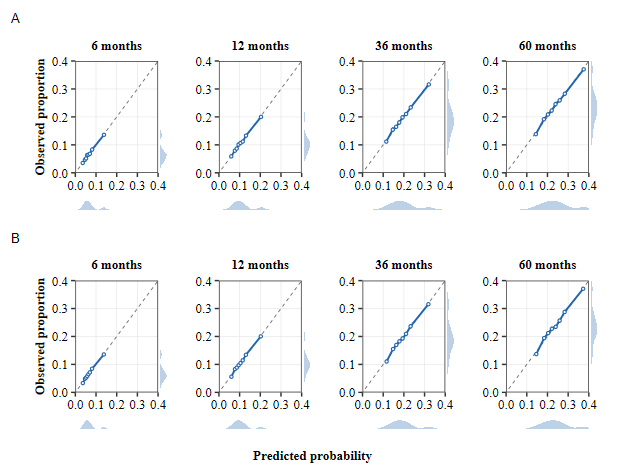

In [21]:
#| label: calibration-plots-readmission

library(ggplot2); library(patchwork)
tnr <- "Times New Roman"

create_cal_published <- function(data, time_title,
                                 color = "#2166AC",
                                 x_lim = c(0, 0.4), x_by = 0.1,
                                 y_lim = x_lim,     y_by = x_by,
                                 show_x_label = FALSE, show_y_label = FALSE) {
  fixed_margin <- ggplot2::margin(5, 2, 5, 5)

  .label_fmt <- function(lim)
    scales::number_format(accuracy = ifelse(diff(lim) <= 0.02, 0.001,
                                     ifelse(diff(lim) <= 0.2,  0.01, 0.1)))

  main <- ggplot2::ggplot(data, ggplot2::aes(x = mean_predicted, y = observed)) +
    ggplot2::geom_abline(intercept = 0, slope = 1, linetype = "dashed",
                         color = "black", linewidth = 0.4, alpha = 0.6) +
    ggplot2::geom_ribbon(ggplot2::aes(ymin = observed_lower, ymax = observed_upper),
                         alpha = 0.3, fill = color) +
    ggplot2::geom_line(color = color, linewidth = 0.9) +
    ggplot2::geom_errorbar(ggplot2::aes(ymin = observed_lower, ymax = observed_upper),
                           width = 0.02 * diff(x_lim), color = color,
                           alpha = 0.6, linewidth = 0.5) +
    ggplot2::geom_point(size = 1, color = color, fill = "white",
                        shape = 21, stroke = 0.8) +
    ggplot2::scale_x_continuous(limits = x_lim, expand = c(0, 0),
                                 breaks = seq(x_lim[1], x_lim[2], by = x_by),
                                 labels = .label_fmt(x_lim)) +
    ggplot2::scale_y_continuous(limits = y_lim, expand = c(0, 0),
                                 breaks = seq(y_lim[1], y_lim[2], by = y_by),
                                 labels = .label_fmt(y_lim)) +
    ggplot2::labs(x = "Predicted probability", y = "Observed proportion",
                  subtitle = time_title) +
    ggplot2::theme_bw(base_size = 15, base_family = tnr) +
    ggplot2::theme(
      plot.subtitle    = ggplot2::element_text(size = 13, face = "bold", hjust = 0.5),
      panel.grid.major = ggplot2::element_line(color = "grey90", linewidth = 0.3),
      panel.grid.minor = ggplot2::element_blank(),
      axis.ticks.length = ggplot2::unit(1.5, "mm"),
      axis.text        = ggplot2::element_text(size = 13, color = "black"),
      axis.title       = ggplot2::element_text(size = 13, face = "bold"),
      axis.title.x     = ggplot2::element_text(
        color = if (show_x_label) "black" else NA, size = 13, face = "bold"),
      axis.title.y     = ggplot2::element_text(
        color = if (show_y_label) "black" else NA, size = 13, face = "bold"),
      plot.margin      = fixed_margin
    )

  right_dens <- ggplot2::ggplot(data, ggplot2::aes(x = observed)) +
    ggplot2::geom_density(fill = color, alpha = 0.3, color = NA) +
    ggplot2::scale_x_continuous(limits = y_lim, expand = c(0, 0)) +
    ggplot2::scale_y_continuous(expand = ggplot2::expansion(mult = c(0, 0.25))) +
    ggplot2::coord_flip() +
    ggplot2::theme_void() +
    ggplot2::theme(plot.margin = ggplot2::margin(5, 5, 5, 0))

  bottom_dens <- ggplot2::ggplot(data, ggplot2::aes(x = mean_predicted)) +
    ggplot2::geom_density(fill = color, alpha = 0.3, color = NA) +
    ggplot2::scale_x_continuous(limits = x_lim, expand = c(0, 0)) +
    ggplot2::scale_y_continuous(expand = ggplot2::expansion(mult = c(0, 0.25))) +
    ggplot2::theme_void() +
    ggplot2::theme(plot.margin = ggplot2::margin(0, 2, 0, 5))

  design <- c(
    patchwork::area(t = 1, l = 1, b = 10, r = 10),
    patchwork::area(t = 1, l = 11, b = 10, r = 11),
    patchwork::area(t = 11, l = 1, b = 11, r = 10)
  )
  main + right_dens + bottom_dens + patchwork::plot_layout(design = design)
}

.make_cal_panel <- function(cal_obj, color, x_lim, x_by,
                            y_lim = x_lim, y_by = x_by) {
  curves <- cal_obj$calibration_curves
  if ("observed_min" %in% names(curves) && !"observed_lower" %in% names(curves)) {
    curves$observed_lower <- curves$observed_min
    curves$observed_upper <- curves$observed_max
  }
  curves <- dplyr::mutate(curves, time_label = paste0(time_months, " months"))
  time_levels <- paste0(sort(unique(curves$time_months)), " months")
  n_plots <- length(time_levels); n_cols <- 4L; n_rows <- ceiling(n_plots / n_cols)

  plots <- lapply(seq_along(time_levels), function(i) {
    col_idx <- (i - 1L) %% n_cols
    row_idx <- (i - 1L) %/% n_cols
    show_y  <- col_idx == 0L
    is_last <- row_idx == (n_rows - 1L)
    n_last  <- n_plots - (n_rows - 1L) * n_cols
    show_x  <- is_last && col_idx == floor((n_last - 1L) / 2L)
    create_cal_published(
      dplyr::filter(curves, time_label == time_levels[i]),
      time_levels[i], color = color,
      x_lim = x_lim, x_by = x_by,
      y_lim = y_lim, y_by = y_by,
      show_x_label = show_x, show_y_label = show_y
    )
  })
  patchwork::wrap_plots(plots, ncol = n_cols) +
    patchwork::plot_annotation(theme = ggplot2::theme(plot.margin = ggplot2::margin(10, 10, 10, 10)))
}

# ── Readmission panels (blue) ─────────────────────────────────────────────────
combined_readmit_full <- .make_cal_panel(cal_results$full_ph,
  color = "#2166AC", x_lim = c(0, 0.4), x_by = 0.1)
combined_readmit_shap <- .make_cal_panel(cal_results$shap_clean,
  color = "#2166AC", x_lim = c(0, 0.4), x_by = 0.1)

final_readmit <- patchwork::wrap_plots(
  patchwork::wrap_elements(combined_readmit_full & ggplot2::theme(axis.title.x = ggplot2::element_blank())),
  patchwork::wrap_elements(combined_readmit_shap & ggplot2::theme(axis.title.x = ggplot2::element_blank())),
  ncol = 1
) +
  patchwork::plot_annotation(
    tag_levels = "A",
    caption = "Predicted probability",
    theme = ggplot2::theme(
      plot.caption = ggplot2::element_text(size = 13, face = "bold", hjust = 0.5, vjust = 1, family = tnr),
      plot.tag     = ggplot2::element_text(face = "bold", size = 18, family = tnr),
      plot.tag.position = c(0.00, 0.97)
    )
  )
print(final_readmit)

ggplot2::ggsave(file.path(project_root, "cons/_figs/readmission_calibration_combined_AB.tiff"),
  final_readmit, width = 17.8 * 1.6, height = 12 * 1.6, units = "cm",
  dpi = 600, compression = "lzw")
ggplot2::ggsave(file.path(project_root, "cons/_figs/readmission_calibration_combined_AB.png"),
  final_readmit, width = 17.8 * 1.6, height = 12 * 1.6, units = "cm", dpi = 600)


There were 16 warnings (use warnings() to see them)


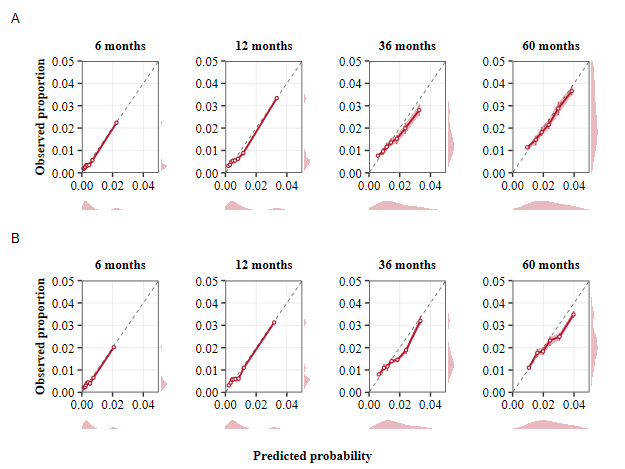

There were 16 warnings (use warnings() to see them)
There were 16 warnings (use warnings() to see them)


In [22]:
#| label: calibration-plots-death

# ── Mortality panels (red) ────────────────────────────────────────────────────
combined_death_full <- .make_cal_panel(death_cal_full$full_ph,
  color = "#B2182B", y_lim = c(0, 0.05), y_by = 0.01, x_lim = c(0, 0.05), x_by = 0.02)
combined_death_shap <- .make_cal_panel(death_cal_full$shap_clean,
  color = "#B2182B", y_lim = c(0, 0.05), y_by = 0.01, x_lim = c(0, 0.05), x_by = 0.02)

final_death <- patchwork::wrap_plots(
  patchwork::wrap_elements(combined_death_full & ggplot2::theme(axis.title.x = ggplot2::element_blank())),
  patchwork::wrap_elements(combined_death_shap & ggplot2::theme(axis.title.x = ggplot2::element_blank())),
  ncol = 1
) +
  patchwork::plot_annotation(
    tag_levels = "A",
    caption = "Predicted probability",
    theme = ggplot2::theme(
      plot.caption      = ggplot2::element_text(size = 13, face = "bold", hjust = 0.5, vjust = 1, family = tnr),
      plot.tag          = ggplot2::element_text(face = "bold", size = 18, family = tnr),
      plot.tag.position = c(0.00, 0.97)
    )
  )
print(final_death)

ggplot2::ggsave(file.path(project_root, "cons/_figs/mortality_calibration_combined_AB.tiff"),
  final_death, width = 17.8 * 1.6, height = 12 * 1.6, units = "cm",
  dpi = 600, compression = "lzw")
ggplot2::ggsave(file.path(project_root, "cons/_figs/mortality_calibration_combined_AB.png"),
  final_death, width = 17.8 * 1.6, height = 12 * 1.6, units = "cm", dpi = 600)


## 3. Dual metrics for pending models

Models that do not yet have dual metrics in `amalisis.xlsx`:
- `formula_readmit` + `formula_death` (Full PH base)
- `formula_readmit_updated` + `formula_death_updated` (Full PH updated)
- `formula_shap_death_interact` (paired with SHAP readmit clean)
- `formula_shap_death` as implementation model (paired with SHAP readmit clean)

We use `k_folds = 5` with `eval_times = c(3, 6, 12, 36, 60)`.

In [23]:
#| label: dual-pending
#| message: false

gc()
# --- Dual metrics for pending models ---
EVAL_TIMES <- c(3, 6, 12, 36, 60)
K_FOLDS <- 5

pending_configs <- list(
  full_ph_base = list(
    label = "Full PH base",
    readmit = if (exists("formula_readmit")) formula_readmit else NULL,
    death = if (exists("formula_death")) formula_death else NULL
  ),
  full_ph_upd = list(
    label = "Full PH updated",
    readmit = if (exists("formula_readmit_updated")) formula_readmit_updated else NULL,
    death = if (exists("formula_death_updated")) formula_death_updated else NULL
  ),
  shap_readmit_clean_death = list(
    label = "SHAP clean readmit + SHAP death interact",
    readmit = if (exists("formula_shap_readmit_clean_updated")) formula_shap_readmit_clean_updated else NULL,
    death = if (exists("formula_death_updated2")) formula_death_updated2 else NULL
  ),
  shap_readmit_clean_death_interact = list(
    label = "SHAP clean readmit + SHAP death interact",
    readmit = if (exists("formula_shap_readmit_clean_updated")) formula_shap_readmit_clean_updated else NULL,
    death = if (exists("formula_shap_death_interact")) formula_shap_death_interact else NULL
  ),
  shap_readmit_interact_death_interact = list(
    label = "SHAP interact readmit + SHAP death interact",
    readmit = if (exists("formula_shap_readmit_interact")) formula_shap_readmit_interact else NULL,
    death = if (exists("formula_shap_death_interact")) formula_shap_death_interact else NULL
  ),
  shap_death_implem = list(
    label = "SHAP clean readmit + SHAP death (13 vars)",
    readmit = if (exists("formula_shap_readmit_clean_updated")) formula_shap_readmit_clean_updated else NULL,
    death = if (exists("formula_shap_death_rule2")) formula_shap_death_rule2 else NULL
  )
)

# Filter configurations with available formulas
pending_configs <- pending_configs[
  sapply(pending_configs, function(x) !is.null(x$readmit) && !is.null(x$death))
]

cat("Pending configurations to evaluate:\n")
for (nm in names(pending_configs)) {
  cat(sprintf("  - %s: %s\n", nm, pending_configs[[nm]]$label))
}

Pending configurations to evaluate:
  - full_ph_base: Full PH base
  - full_ph_upd: Full PH updated
  - shap_readmit_clean_death: SHAP clean readmit + SHAP death interact
  - shap_readmit_clean_death_interact: SHAP clean readmit + SHAP death interact
  - shap_readmit_interact_death_interact: SHAP interact readmit + SHAP death interact
  - shap_death_implem: SHAP clean readmit + SHAP death (13 vars)


In [24]:
#| label: run-dual-pending
#| message: false
#| cache: false

dual_pending_results <- list()

for (nm in names(pending_configs)) {
  cfg <- pending_configs[[nm]]
  cat(sprintf("\n=== Dual: %s ===\n", cfg$label))
  flush.console()
  
  dual_pending_results[[nm]] <- evaluate_dual_cox_python_style(
    formula_readmit = cfg$readmit,
    formula_death = cfg$death,
    imputed_list = py_corrected_datasets_boot,
    k_folds = K_FOLDS,
    eval_times = EVAL_TIMES
  )
  
  cat(sprintf("  OK - %s\n", cfg$label))
  print(dual_pending_results[[nm]]$summary[dual_pending_results[[nm]]$summary$Time %in% c("6","12","36","60","Global"), ])
  flush.console()
}


=== Dual: Full PH base ===
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
  OK - Full PH base
          Risk        Metric   Time       mean          sd       q025
2        Death           IBS      6 0.01959954 0.003001260 0.01450061
3        Death           IBS     12 0.02607606 0.003543701 0.02028295
4        Death           IBS     36 0.04890563 0.003981075 0.04262698
5        Death           IBS     60 0.06751310 0.004216797 0.06024073
6        Death           IBS Global 0.06751310 0.004216797 0.06024073
8        Death Uno's C-Index      6 0.76365180 0.035760072 0.69819660
9        Death Uno's C-Index     12 0.75718718 0.025375236 0.71003208
10       Death Uno's C-Index     36 0.76344594 0.012277779 0.74355591
11       Death Uno's C-Index     60 0.76255964 0.010959523 0.74712159
12       Death Uno's C-Index Global 0.74214997 0.010699318 0.72321439
14 Readmission           IBS      6 0

~ 18 minutes


## 5. Consolidated model table

Builds a table with all candidate models and their main dual metrics.

In [25]:
#| label: extract-metrics
#| message: false

# --- Helper to extract metrics from an evaluate_dual_cox_python_style object ---
extract_dual_metrics <- function(obj, model_id, family) {
  if (is.null(obj) || !is.list(obj) || is.null(obj$summary)) {
    return(NULL)
  }
  
  s <- obj$summary
  
  # Global
  row_global <- s[s$Time == "Global", ]
  
  # Dual UnoC = (UnoC_readmit + UnoC_death) / 2
  unoc_r <- row_global$mean[row_global$Metric == "Uno's C-Index" & row_global$Risk == "Readmission"]
  unoc_d <- row_global$mean[row_global$Metric == "Uno's C-Index" & row_global$Risk == "Death"]
  dual_unoC <- if (length(unoc_r) == 1 && length(unoc_d) == 1) (unoc_r + unoc_d) / 2 else NA
  
  # Dual IBS = (IBS_readmit + IBS_death) / 2
  ibs_r <- row_global$mean[row_global$Metric == "IBS" & row_global$Risk == "Readmission"]
  ibs_d <- row_global$mean[row_global$Metric == "IBS" & row_global$Risk == "Death"]
  dual_ibs <- if (length(ibs_r) == 1 && length(ibs_d) == 1) (ibs_r + ibs_d) / 2 else NA
  
  # By horizon (d_C_T, d_IBS_T)
  d_C_T <- list()
  d_IBS_T <- list()
  for (t in c("6", "12", "36", "60")) {
    s_t <- s[s$Time == t, ]
    if (nrow(s_t) > 0) {
      c_r <- s_t$mean[s_t$Metric == "Uno's C-Index" & s_t$Risk == "Readmission"]
      c_d <- s_t$mean[s_t$Metric == "Uno's C-Index" & s_t$Risk == "Death"]
      d_C_T[[t]] <- if (length(c_r) == 1 && length(c_d) == 1) (c_r + c_d) / 2 else NA
      
      ibs_r <- s_t$mean[s_t$Metric == "IBS" & s_t$Risk == "Readmission"]
      ibs_d <- s_t$mean[s_t$Metric == "IBS" & s_t$Risk == "Death"]
      d_IBS_T[[t]] <- if (length(ibs_r) == 1 && length(ibs_d) == 1) (ibs_r + ibs_d) / 2 else NA
    }
  }
  
  # Pooled individual
  unoc_readmit <- if (length(unoc_r) == 1) unoc_r else NA
  unoc_death <- if (length(unoc_d) == 1) unoc_d else NA
  ibs_readmit <- if (length(ibs_r) == 1) ibs_r else NA
  ibs_death <- if (length(ibs_d) == 1) ibs_d else NA
  
  data.frame(
    model_id = model_id,
    family = family,
    dual_UnoC = round(dual_unoC, 4),
    dual_IBS = round(dual_ibs, 4),
    d_C_6 = round(d_C_T[["6"]], 4),
    d_C_12 = round(d_C_T[["12"]], 4),
    d_C_36 = round(d_C_T[["36"]], 4),
    d_C_60 = round(d_C_T[["60"]], 4),
    d_IBS_6 = round(d_IBS_T[["6"]], 4),
    d_IBS_12 = round(d_IBS_T[["12"]], 4),
    d_IBS_36 = round(d_IBS_T[["36"]], 4),
    d_IBS_60 = round(d_IBS_T[["60"]], 4),
    UnoC_readmit = round(unoc_readmit, 4),
    UnoC_death = round(unoc_death, 4),
    IBS_readmit = round(ibs_readmit, 4),
    IBS_death = round(ibs_death, 4),
    stringsAsFactors = FALSE
  )
}

cat("Helper function extract_dual_metrics defined.\n")

Helper function extract_dual_metrics defined.


In [26]:
dual_pending_results$full_ph_upd$summary |>
  dplyr::filter(Time %in% c("6","12","36","60","Global")) |>
  dplyr::arrange(desc(Risk)) |> knitr::kable("markdown")



|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.1519521| 0.0090317| 0.1370376| 0.1660101| 25|
|Readmission |IBS           |12     | 0.2003654| 0.0092655| 0.1837179| 0.2136667| 25|
|Readmission |IBS           |36     | 0.2854071| 0.0087159| 0.2662987| 0.2976492| 25|
|Readmission |IBS           |60     | 0.3252959| 0.0081484| 0.3071633| 0.3356612| 25|
|Readmission |IBS           |Global | 0.3252959| 0.0081484| 0.3071633| 0.3356612| 25|
|Readmission |Uno's C-Index |6      | 0.6388001| 0.0076951| 0.6279740| 0.6504659| 25|
|Readmission |Uno's C-Index |12     | 0.6286976| 0.0056091| 0.6179932| 0.6374001| 25|
|Readmission |Uno's C-Index |36     | 0.6145609| 0.0041140| 0.6077500| 0.6213650| 25|
|Readmission |Uno's C-Index |60     | 0.6097046| 0.0041880| 0.6035673| 0.6177471| 25|
|Readmission |Uno's C-Index |Global | 0.6040678| 0.0

In [28]:
#| label: build-table
#| message: false

# --- List of all available result objects ---
# Objects from prediction22 (should be in the environment)
result_objects <- list(
  # Full PH family
  full_ph_base = list(
    obj = if (exists("dual_pending_results")) dual_pending_results$full_ph_base else NULL,
    id = "formula_readmit + formula_death",
    fam = "Full PH"
  ),
  full_ph_upd = list(
    obj = if (exists("dual_pending_results")) dual_pending_results$full_ph_upd else NULL,
    id = "formula_readmit_updated + formula_death_updated",
    fam = "Full PH"
  ),
  full_ph_upd2 = list(
    obj = if (exists("results_upd2_py")) results_upd2_py else NULL,
    id = "formula_readmit_updated2 + formula_death_updated2",
    fam = "Full PH"
  ),
  
  # xgb2 family (SHAP)
  shap_clean = list(
    obj = if (exists("results_shap_xgb_py_upd_best_perf")) results_shap_xgb_py_upd_best_perf else NULL,
    id = "formula_shap_readmit_clean_updated + formula_death_updated2",
    fam = "xgb2"
  ),
  shap_death_implem = list(
    obj = if (exists("dual_pending_results")) dual_pending_results$shap_death_implem else NULL,
    id = "formula_shap_readmit_clean_updated + formula_shap_death_rule2",
    fam = "xgb2"
  ),
  shap_readmit_interact = list(
    obj = if (exists("results_shap_xgb_py_upd_best_perf3")) results_shap_xgb_py_upd_best_perf3 else NULL,
    id = "formula_shap_readmit_interact + formula_death_updated2",
    fam = "xgb2"
  ),
  shap_readmit_clean_death_interact = list(
    obj = if (exists("dual_pending_results")) dual_pending_results$shap_readmit_clean_death_interact else NULL,
    id = "formula_shap_readmit_clean_updated + formula_shap_death_interact",
    fam = "xgb2"
  ),
  shap_readmit_interact_death_interact = list(
    obj = if (exists("dual_pending_results")) dual_pending_results$shap_readmit_interact_death_interact else NULL,
    id = "formula_shap_readmit_interact + formula_shap_death_interact",
    fam = "xgb2"
  )#,
  
  # # DS family
  # ds_clean = list(
  #   obj = if (exists("ds_dual_results")) ds_dual_results$ds_readmit_clean_ds_death else NULL,
  #   id = "formula_shap_ds_readmit_clean_updated + formula_shap_ds_death_updated",
  #   fam = "ds"
  # ),
  # ds_interact = list(
  #   obj = if (exists("ds_dual_results")) ds_dual_results$ds_readmit_interact_ds_death else NULL,
  #   id = "formula_shap_ds_readmit_interact + formula_shap_ds_death_updated",
  #   fam = "ds"
  # ),
  # ds_readmit_clean_full_death = list(
  #   obj = if (exists("ds_dual_results")) ds_dual_results$ds_readmit_clean_full_death else NULL,
  #   id = "formula_shap_ds_readmit_clean_updated + formula_death_updated2",
  #   fam = "ds"
  # )
)

# --- Extract metrics ---
table_rows <- lapply(names(result_objects), function(nm) {
  entry <- result_objects[[nm]]
  if (is.null(entry$obj)) return(NULL)
  extract_dual_metrics(entry$obj, entry$id, entry$fam)
})
table_rows <- table_rows[!sapply(table_rows, is.null)]

if (length(table_rows) > 0) {
  consolidated_table <- do.call(rbind, table_rows)
  rownames(consolidated_table) <- NULL
  
  cat("=== CONSOLIDATED TABLE OF DUAL METRICS ===\n\n")
  knitr::kable(consolidated_table, row.names = FALSE, format = "markdown")

  # Save
  write.csv(consolidated_table,
            file.path(project_root, "cons", "_out", "tabla_consolidada_dual.csv"),
            row.names = FALSE)
  cat("\nSaved to: cons/_out/tabla_consolidada_dual.csv\n")
} else {
  cat("No rows to consolidate. Run the previous sections first.\n")
}

=== CONSOLIDATED TABLE OF DUAL METRICS ===


Saved to: cons/_out/tabla_consolidada_dual.csv



## 6. ICI consolidated by horizon

Extract ICI at 6, 12, 36, 60 months and build a table + plot.

=== ICI / ECE / E-O for READMISSION models ===

                     model     outcome time    ICI ICI_sd    ECE    E_O
      SHAP clean (primary) Readmission    6 0.0068  1e-04 0.0022 0.9905
      SHAP clean (primary) Readmission   12 0.0079  1e-04 0.0030 0.9908
      SHAP clean (primary) Readmission   36 0.0093  1e-04 0.0045 0.9890
      SHAP clean (primary) Readmission   60 0.0096  1e-04 0.0061 0.9857
                   Full PH Readmission    6 0.0065  1e-04 0.0022 0.9898
                   Full PH Readmission   12 0.0080  1e-04 0.0027 0.9900
                   Full PH Readmission   36 0.0096  3e-04 0.0039 0.9881
                   Full PH Readmission   60 0.0103  3e-04 0.0051 0.9848
       SHAP + interactions Readmission    6 0.0070  1e-04 0.0023 0.9906
       SHAP + interactions Readmission   12 0.0080  2e-04 0.0027 0.9909
       SHAP + interactions Readmission   36 0.0094  2e-04 0.0046 0.9891
       SHAP + interactions Readmission   60 0.0098  1e-04 0.0066 0.9857
    Base (readmi

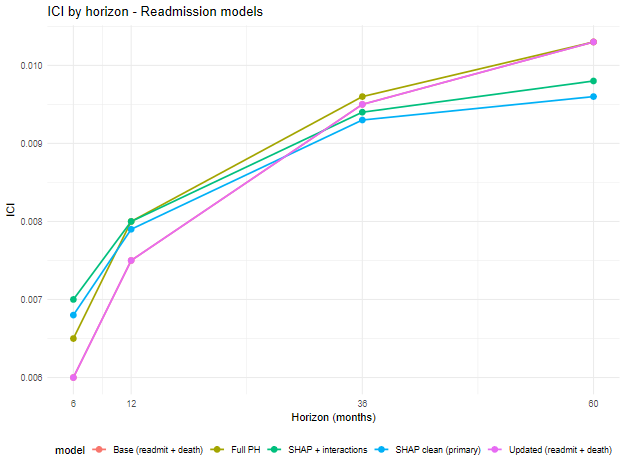

In [29]:
#| label: ici-table
#| message: false

# --- ICI for readmission ---
ici_readmit_rows <- list()

if (exists("cal_results")) {
  for (nm in names(cal_results)) {
    label <- readmit_models_for_cal[[nm]]$label
    ps <- cal_results[[nm]]$pooled_summary
    for (i in seq_len(nrow(ps))) {
      if (ps$time_months[i] %in% c(6, 12, 36, 60)) {
        ici_readmit_rows[[length(ici_readmit_rows) + 1]] <- data.frame(
          model = label,
          outcome = "Readmission",
          time = ps$time_months[i],
          ICI = round(ps$ici_mean[i], 4),
          ICI_sd = round(ps$ici_sd[i], 4),
          ECE = round(ps$ece_mean[i], 4),
          E_O = round(ps$eo_mean[i], 4),
          stringsAsFactors = FALSE
        )
      }
    }
  }
}

if (length(ici_readmit_rows) > 0) {
  ici_readmit_table <- do.call(rbind, ici_readmit_rows)
  cat("=== ICI / ECE / E-O for READMISSION models ===\n\n")
  print(ici_readmit_table, row.names = FALSE)
  
  write.csv(ici_readmit_table,
            file.path(project_root, "cons", "_out", "ici_readmit_multihorizonte.csv"),
            row.names = FALSE)
  
  # Plot
  if (requireNamespace("ggplot2", quietly = TRUE)) {
    p <- ggplot2::ggplot(ici_readmit_table,
                         ggplot2::aes(x = time, y = ICI, color = model, group = model)) +
      ggplot2::geom_line(linewidth = 0.8) +
      ggplot2::geom_point(size = 2.5) +
      ggplot2::scale_x_continuous(breaks = c(6, 12, 36, 60)) +
      ggplot2::labs(title = "ICI by horizon - Readmission models",
                    x = "Horizon (months)", y = "ICI") +
      ggplot2::theme_minimal() +
      ggplot2::theme(legend.position = "bottom")
    print(p)
  }
} else {
  cat("No ICI data available. Run section 2 first.\n")
}

=== ICI / ECE / E-O for MORTALITY models ===

               model   outcome time    ICI    ECE    E_O
   Full PH (primary) Mortality    6 0.0024 0.0007 1.0069
   Full PH (primary) Mortality   12 0.0031 0.0010 1.0096
   Full PH (primary) Mortality   36 0.0067 0.0023 1.0142
   Full PH (primary) Mortality   60 0.0091 0.0025 1.0246
      SHAP (13 vars) Mortality    6 0.0017 0.0007 1.0073
      SHAP (13 vars) Mortality   12 0.0027 0.0010 1.0092
      SHAP (13 vars) Mortality   36 0.0067 0.0024 1.0151
      SHAP (13 vars) Mortality   60 0.0094 0.0026 1.0277
 SHAP + interactions Mortality    6 0.0018 0.0009 1.0069
 SHAP + interactions Mortality   12 0.0027 0.0013 1.0086
 SHAP + interactions Mortality   36 0.0068 0.0028 1.0147
 SHAP + interactions Mortality   60 0.0091 0.0029 1.0284
          Base death Mortality    6 0.0017 0.0006 1.0078
          Base death Mortality   12 0.0027 0.0011 1.0098
          Base death Mortality   36 0.0067 0.0025 1.0117
          Base death Mortality   60 0.0089

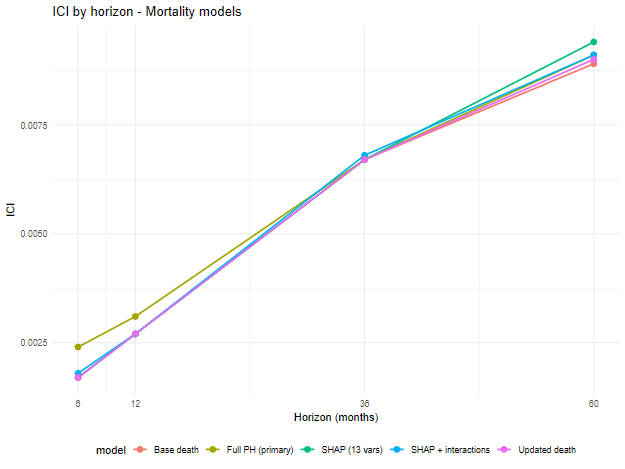

In [30]:
#| label: ici-death-table
#| message: false

if (exists("death_cal_results") && length(death_cal_results) > 0) {
  ici_death_rows <- list()
  for (nm in names(death_cal_results)) {
    label <- death_models_for_cal[[nm]]$label
    df <- death_cal_results[[nm]]
    for (i in seq_len(nrow(df))) {
      ici_death_rows[[length(ici_death_rows) + 1]] <- data.frame(
        model = label,
        outcome = "Mortality",
        time = df$time_months[i],
        ICI = round(df$ici[i], 4),
        ECE = round(df$ece[i], 4),
        E_O = round(df$eo_ratio[i], 4),
        stringsAsFactors = FALSE
      )
    }
  }
  
  ici_death_table <- do.call(rbind, ici_death_rows)
  cat("=== ICI / ECE / E-O for MORTALITY models ===\n\n")
  print(ici_death_table, row.names = FALSE)
  
  write.csv(ici_death_table,
            file.path(project_root, "cons", "_out", "ici_death_multihorizonte.csv"),
            row.names = FALSE)
  
  if (requireNamespace("ggplot2", quietly = TRUE)) {
    p <- ggplot2::ggplot(ici_death_table,
                         ggplot2::aes(x = time, y = ICI, color = model, group = model)) +
      ggplot2::geom_line(linewidth = 0.8) +
      ggplot2::geom_point(size = 2.5) +
      ggplot2::scale_x_continuous(breaks = c(6, 12, 36, 60)) +
      ggplot2::labs(title = "ICI by horizon - Mortality models",
                    x = "Horizon (months)", y = "ICI") +
      ggplot2::theme_minimal() +
      ggplot2::theme(legend.position = "bottom")
    print(p)
  }
} else {
  cat("No ICI data for death available. Run section 2b first.\n")
}


## 7. DCA (Decision Curve Analysis)

Evaluates the net benefit of using the model for clinical decisions
at different probability thresholds.

But we uniform the grid of integration from 6 to 60 months (2026-05-30).

In [31]:
#| label: dca-setup
#| message: false

source("cons/_alt_scripts/adca_from_results_boot.R")            # fuerza motor AJ
source("cons/_alt_scripts/dca_from_results_boot_for_metrics.R")
cat("Sourced: dca_from_results_boot_for_metrics\n")


Sourced: dca_from_results_boot_for_metrics


In [32]:
#| label: full-criteria-upd2-run-ev-mi-cv-python-style-from-step22
if (!exists("results_upd2_py")){
  results_upd2_py <- evaluate_dual_cox_python_style(
    formula_readmit = formula_readmit_updated2,
    formula_death = formula_death_updated2,
    imputed_list = py_corrected_datasets,
    k_folds = 5,
    eval_times = c(3, 6, 12, 36, 60)
  )
}

# Load the precomputed post-interaction death-side models instead of recomputing
# (each ~64 MB, saved strip=FALSE). Picks the newest matching RDS by mtime.
out_dir <- file.path(project_root, "data", "20241015_out")

.load_latest_rds <- function(suffix) {
  f <- list.files(out_dir, pattern = paste0("pred22_ndp_.*__", suffix, "\\.rds$"),
                  full.names = TRUE)
  if (!length(f)) stop(sprintf("No RDS found for '%s' in %s", suffix, out_dir))
  f <- f[order(file.info(f)$mtime, decreasing = TRUE)][1]   # newest
  message("Loading: ", basename(f))
  readRDS(f)
}

# results_shap_xgb_py_upd_post_int_alt1 <- evaluate_dual_cox_python_style(
#   formula_readmit = formula_shap_readmit_clean_updated,
#   formula_death = formula_death_updated2,
#   imputed_list = py_corrected_datasets_boot,
#   k_folds = 5,
#   eval_times = c(3,6,12,36,60)   # igual que todos los experimentos
# )

# results_shap_xgb_py_upd_post_int_alt2 <- evaluate_dual_cox_python_style(
#   formula_readmit = formula_shap_readmit_clean_updated,
#   formula_death = formula_shap_death_rule2,
#   imputed_list = py_corrected_datasets_boot,
#   k_folds = 5,
#   eval_times = c(3,6,12,36,60)   # igual que todos los experimentos
# )
if (!exists("results_shap_xgb_py_upd_best_perf")){
  results_shap_xgb_py_upd_best_perf <- .load_latest_rds("dual_shap_int_d_fullph")  # SHAP death rule2results_shap_xgb_py_upd_post_int_alt1 <- .load_latest_rds("dual_shap_int_d_fullph")    # Full PH death
}
if (!exists("results_shap_xgb_py_upd_best_perf2")){
  results_shap_xgb_py_upd_best_perf2 <- .load_latest_rds("dual_shap_int_d_shap_rule")  # SHAP death rule2
}
  

Loading: pred22_ndp_2026_06_18__dual_shap_int_d_fullph.rds
Loading: pred22_ndp_2026_06_18__dual_shap_int_d_shap_rule.rds


In [33]:
#| label: dca-run
#| message: false
#| cache: false

DCA_HORIZONS <- c(6, 12, 36, 60)

dca_model_list <- list(
  full_ph     = results_upd2_py,
  shap_clean  = results_shap_xgb_py_upd_best_perf,
  implemented = results_shap_xgb_py_upd_best_perf2
)

# Compute the full DCA ONCE per model (covers BOTH risks + full summary in a
# single pass). This is the ONLY expensive step; everything else is derived.
dca_models_full <- run_dca_full_summary(dca_model_list, horizons = DCA_HORIZONS)

# Derive the compact per-horizon format (what plot_dca_multi_horizon expects)
# from the already-computed summaries — NO recomputation. Identical to what
# compute_dca_from_boot() would return (same run_adca config, same thresholds).
.dca_compact_from_full <- function(models_full, risk, horizons,
                                   thresholds = seq(0.01, 0.60, by = 0.01)) {
  out <- stats::setNames(vector("list", length(horizons)), as.character(horizons))
  for (h in horizons) {
    per_model <- lapply(models_full, function(m) {
      if (is.null(m)) return(NULL)
      if (!(h %in% as.numeric(m$config$horizons))) return(NULL)
      .dca_extract_horizon(m, risk, h, thresholds)
    })
    out[[as.character(h)]] <- stats::setNames(per_model, names(models_full))
  }
  out
}

dca_readmit <- .dca_compact_from_full(dca_models_full, "readmission", DCA_HORIZONS)
dca_death   <- .dca_compact_from_full(dca_models_full, "death",       DCA_HORIZONS)
cat("DCA computed once per model; readmission + mortality derived (no recompute).\n")


  DCA full summary: full_ph | horizons=6, 12, 36, 60
Readmission observed risk: Aalen-Johansen on 25/25 replicate(s). Death: Kaplan-Meier.
  DCA full summary: shap_clean | horizons=6, 12, 36, 60
Readmission observed risk: Aalen-Johansen on 25/25 replicate(s). Death: Kaplan-Meier.
  DCA full summary: implemented | horizons=6, 12, 36, 60
Readmission observed risk: Aalen-Johansen on 25/25 replicate(s). Death: Kaplan-Meier.
DCA computed once per model; readmission + mortality derived (no recompute).


~28 minutes

In [34]:
#| label: dca-summary-and-panel
#| message: false

# dca_models_full already exists from the dca-run chunk — do NOT recompute.
stopifnot(exists("dca_models_full"))

# Net-benefit summaries per model
dca_nb_full_ph          <- summarize_dca_nb(dca_models_full$full_ph$summary)
dca_nb_shap_clean       <- summarize_dca_nb(dca_models_full$shap_clean$summary)
dca_nb_shap_implemented <- summarize_dca_nb(dca_models_full$implemented$summary)

cat("=== Full PH — useful threshold ranges ===\n")
print(dca_nb_full_ph$any_useful)
cat("\n=== SHAP clean — focus window summary ===\n")
print(dca_nb_shap_clean$focus_summary)
cat("\n=== Both SHAP — focus window summary ===\n")
print(dca_nb_shap_implemented$focus_summary)


=== Full PH — useful threshold ranges ===
# A tibble: 8 × 8
  risk     horizon any_useful_anywhere useful_threshold_min useful_threshold_max
  <chr>      <dbl> <lgl>                              <dbl>                <dbl>
1 death          6 TRUE                                0.01                 0.16
2 death         12 TRUE                                0.01                 0.24
3 death         36 TRUE                                0.01                 0.5 
4 death         60 TRUE                                0.02                 0.37
5 readmis…       6 TRUE                                0.02                 0.26
6 readmis…      12 TRUE                                0.03                 0.4 
7 readmis…      36 TRUE                                0.06                 0.5 
8 readmis…      60 TRUE                                0.07                 0.5 
# ℹ 3 more variables: max_model_nb <dbl>, max_treat_all_nb <dbl>,
#   max_treat_none_nb <dbl>

=== SHAP clean — focus window summa

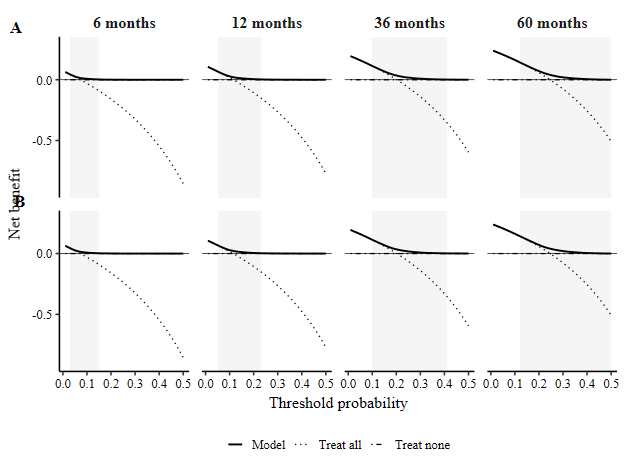

DCA results saved to cons/_out/dca_results.rds
(A = Full PH, B = SHAP clean / implemented)


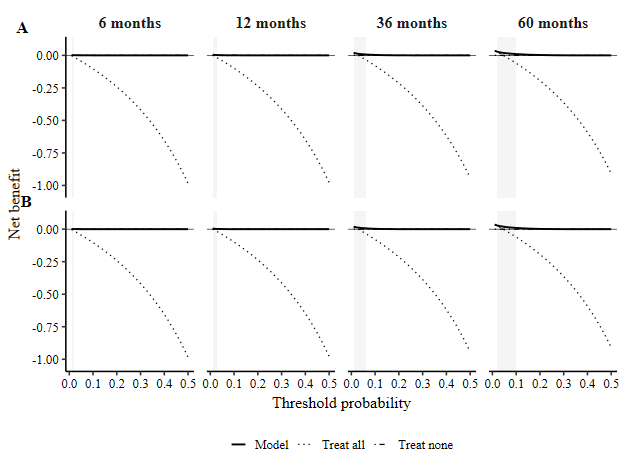

In [35]:
#| label: dca-panel-figures
#| message: false

p_readmit_panel <- make_dca_panel_figure(
  summary_full = dca_models_full$full_ph$summary,
  summary_ml   = dca_models_full$shap_clean$summary,
  outcome      = "readmission",
  horizons     = c(6, 12, 36, 60)
)
  # ggplot2::labs(
  #   caption = "A: Full PH readmission model; B: SHAP-clean readmission model"
  # )
print(p_readmit_panel)

p_death_panel <- make_dca_panel_figure(
  summary_full = dca_models_full$full_ph$summary,
  summary_ml   = dca_models_full$implemented$summary,
  outcome      = "death",
  horizons     = c(6, 12, 36, 60)
)
  # ggplot2::labs(
  #   caption = "A: Full PH mortality model; B: parsimonious SHAP mortality implementation model"
  # )
print(p_death_panel)

saveRDS(
  list(
    readmit = dca_readmit,
    death   = dca_death,
    models_full = dca_models_full,
    nb_full_ph = dca_nb_full_ph,
    nb_shap_clean = dca_nb_shap_clean,
    nb_implemented = dca_nb_shap_implemented
  ),
  file.path(project_root, "data", "20241015_out", "dca_results.rds")
)
cat("DCA results saved to cons/_out/dca_results.rds\n")
cat("(A = Full PH, B = SHAP clean / implemented)\n")

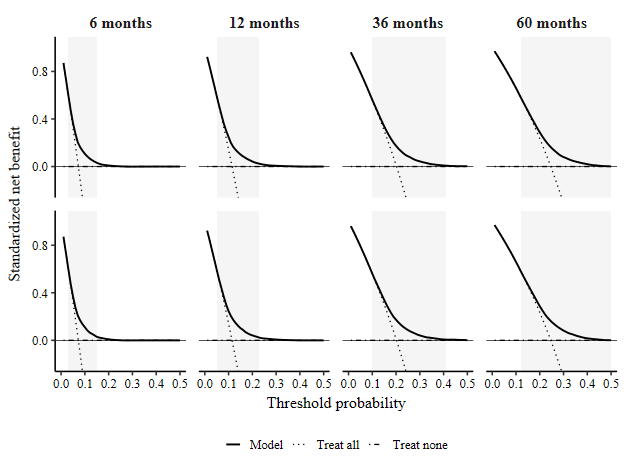

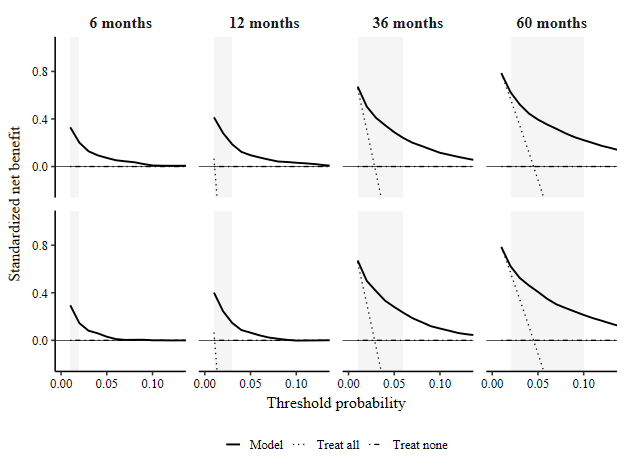

Standardized net benefit = net benefit / observed event rate at each horizon
(1.0 = treating everyone at threshold 0). The 'treat all' curve may fall below the
displayed range. Shaded band: plausible threshold window (0.5x to 2x the event rate).


In [36]:
#| label: dca-panel-figures-std
#| message: false

# Standardized-net-benefit variant of make_dca_panel_figure().
# Standalone: does NOT modify the shared make_dca_panel_figure() in
# dca_from_results_boot_for_metrics.R, so other callers stay intact.
# What changed vs the original:
#   - y axis = standardized net benefit = net_benefit_mean / observed event rate,
#     so the model curve is visible and comparable across horizons.
#   - x axis truncated per outcome (data-driven from the focus windows); high
#     thresholds are clinically irrelevant for rare outcomes (death stays tight).
#   - y axis cropped to the meaningful range; "treat all" may run off the bottom.
#   - a caption note below the plot states the standardization.

make_dca_panel_figure_std <- function(
    summary_full,
    summary_ml,
    outcome  = c("death", "readmission"),
    horizons = c(6, 12, 36, 60),
    x_limits = NULL,             # NULL = data-driven from the focus windows
    y_limits = c(-0.2, 1.03)     # standardized scale: 1.0 = treat-all at threshold 0
) {
  stopifnot(requireNamespace("ggplot2", quietly = TRUE))
  outcome <- match.arg(outcome)

  full_dat <- summary_full; full_dat$model_panel <- "A"
  ml_dat   <- summary_ml;   ml_dat$model_panel   <- "B"
  plot_dat <- rbind.data.frame(full_dat, ml_dat)
  plot_dat <- plot_dat[plot_dat$risk %in% outcome &
                         plot_dat$horizon %in% horizons, , drop = FALSE]
  if (!nrow(plot_dat)) stop("No rows for the requested outcome/horizons.", call. = FALSE)

  # Standardized net benefit = net benefit / event prevalence at the horizon.
  prev <- plot_dat$observed_event_risk_mean
  plot_dat$std_nb <- ifelse(is.finite(prev) & prev > 0,
                            plot_dat$net_benefit_mean / prev, NA_real_)

  plot_dat$strategy_plot <- factor(plot_dat$strategy,
                                   levels = c("Model", "Treat all", "Treat none"))
  plot_dat$model_panel   <- factor(plot_dat$model_panel, levels = c("A", "B"))
  plot_dat$horizon       <- factor(plot_dat$horizon, levels = horizons)

  focus_dat <- plot_dat[!duplicated(plot_dat[, c("model_panel", "horizon",
                                                 "focus_lower", "focus_upper")]), ,
                        drop = FALSE]

  # Data-driven x truncation: cover the focus windows + margin, capped at 0.5
  # (death collapses to a tight low-threshold range; readmission keeps its width).
  if (is.null(x_limits)) {
    x_hi <- min(0.5, max(focus_dat$focus_upper, na.rm = TRUE) * 1.3)
    x_limits <- c(0, x_hi)
  }

  ggplot2::ggplot() +
    ggplot2::geom_rect(
      data = focus_dat,
      ggplot2::aes(xmin = focus_lower, xmax = focus_upper, ymin = -Inf, ymax = Inf),
      inherit.aes = FALSE, fill = "grey80", alpha = 0.18, color = NA
    ) +
    ggplot2::geom_hline(yintercept = 0, linewidth = 0.3) +
    ggplot2::geom_line(
      data = plot_dat,
      ggplot2::aes(x = threshold, y = std_nb,
                   linetype = strategy_plot, linewidth = strategy_plot)
    ) +
    ggplot2::facet_grid(
      model_panel ~ horizon, switch = "y",
      labeller = ggplot2::labeller(horizon = function(x) paste0(x, " months"))
    ) +
    ggplot2::scale_linetype_manual(
      values = c("Model" = "solid", "Treat all" = "dotted", "Treat none" = "dotdash")
    ) +
    ggplot2::scale_linewidth_manual(
      values = c("Model" = 0.9, "Treat all" = 0.6, "Treat none" = 0.6)
    ) +
    ggplot2::coord_cartesian(xlim = x_limits, ylim = y_limits, clip = "on") +
    ggplot2::labs(
      x = "Threshold probability",
      y = "Standardized net benefit",
      linetype = NULL, linewidth = NULL)+
    #   caption = paste(
    #     "Standardized net benefit = net benefit / observed event rate at each horizon",
    #     "(1.0 = treating everyone at threshold 0). The 'treat all' curve may fall below the",
    #     "displayed range. Shaded band: plausible threshold window (0.5x to 2x the event rate).",
    #     sep = "\n")
    # ) +
    ggplot2::theme_classic(base_size = 16, base_family = "Times New Roman") +
    ggplot2::theme(
      legend.position   = "bottom",
      legend.box        = "horizontal",
      strip.background  = ggplot2::element_blank(),
      strip.placement   = "outside",
      strip.text.y.left = ggplot2::element_blank(),
      strip.text.x      = ggplot2::element_text(face = "bold", size = 16, hjust = 0.5),
      axis.text         = ggplot2::element_text(color = "black"),
      axis.title        = ggplot2::element_text(face = "plain"),
      panel.spacing     = ggplot2::unit(0.9, "lines"),
      plot.caption      = ggplot2::element_text(hjust = 0, size = 10, face = "italic")
    )
}

# Rebuild both panels with the standardized variant (same inputs as before)
p_readmit_panel <- make_dca_panel_figure_std(
  summary_full = dca_models_full$full_ph$summary,
  summary_ml   = dca_models_full$shap_clean$summary,
  outcome      = "readmission",
  horizons     = c(6, 12, 36, 60)
)
print(p_readmit_panel)

p_death_panel <- make_dca_panel_figure_std(
  summary_full = dca_models_full$full_ph$summary,
  summary_ml   = dca_models_full$implemented$summary,
  outcome      = "death",
  horizons     = c(6, 12, 36, 60)
)
print(p_death_panel)

# Save. Same filenames -> replaces the current manuscript figures.
# Add a "_std" suffix in `nm` below if you want to keep both versions.
fig_dir <- file.path(project_root, "cons", "_figs")
if (!dir.exists(fig_dir)) dir.create(fig_dir, recursive = TRUE)

for (nm in c("p_dca_readmit_fullph_vs_shap_clean",
             "p_dca_death_fullph_vs_shap_implemented")) {
  obj <- if (grepl("readmit", nm)) p_readmit_panel else p_death_panel
  ggplot2::ggsave(file.path(fig_dir, paste0(nm, ".png")), obj,
                  width = 17.8 * 1.2, height = 12 * 1.2, units = "cm", dpi = 600)
  ggplot2::ggsave(file.path(fig_dir, paste0(nm, ".pdf")), obj,
                  width = 17.8 * 1.2, height = 12 * 1.2, units = "cm",
                  device = grDevices::cairo_pdf)
}
message(paste(
        "Standardized net benefit = net benefit / observed event rate at each horizon",
        "(1.0 = treating everyone at threshold 0). The 'treat all' curve may fall below the",
        "displayed range. Shaded band: plausible threshold window (0.5x to 2x the event rate).",
        sep = "\n"))

- Standardized net benefit plotted so the model curve is visible and comparable across horizons; absolute net benefit reported below for clinical magnitude.
- Across both outcomes and all horizons, the model beats treat all and treat none throughout the plausible threshold window.
- Net benefit reads as net true cases correctly flagged per 1,000 patients, with no net penalty from false alarms.
- **Readmission**= Up to ~44 / 1,000 at 6 months, ~68 / 1,000 at 12 months, ~104 / 1,000 at 36 months, ~134 / 1,000 at 60 months.
- Read as: targeting with the model is equivalent to correctly identifying ~68 future readmissions per 1,000 discharged patients at 12 months, at no net cost in unnecessary referrals.
- **Mortality**= Up to ~2 / 1,000 at 6 months, ~4 / 1,000 at 12 months, ~19 / 1,000 at 36 months, ~28 / 1,000 at 60 months.
- standardized scale (0.3–0.8) reflects the fraction of achievable benefit captured, not large numbers of people.

In [37]:
#| label: dca-panel-export
#| message: false

fig_dir <- file.path(project_root, "cons", "_figs")
if (!dir.exists(fig_dir)) dir.create(fig_dir, recursive = TRUE)

ggplot2::ggsave(
  file.path(fig_dir, "p_dca_readmit_fullph_vs_shap_clean.png"),
  p_readmit_panel,
  width = 17.8 * 1.2, height = 12 * 1.2, units = "cm", dpi = 600
)
ggplot2::ggsave(
  file.path(fig_dir, "p_dca_readmit_fullph_vs_shap_clean.pdf"),
  p_readmit_panel,
  width = 17.8 * 1.2, height = 12 * 1.2, units = "cm",
  device = grDevices::cairo_pdf
)

ggplot2::ggsave(
  file.path(fig_dir, "p_dca_death_fullph_vs_shap_implemented.png"),
  p_death_panel,
  width = 17.8 * 1.2, height = 12 * 1.2, units = "cm", dpi = 600
)
ggplot2::ggsave(
  file.path(fig_dir, "p_dca_death_fullph_vs_shap_implemented.pdf"),
  p_death_panel,
  width = 17.8 * 1.2, height = 12 * 1.2, units = "cm",
  device = grDevices::cairo_pdf
)

### NRI & IDI

In [38]:
#| label: nri-idi-epi-table-models-html
#| message: false
#| results: asis

source(file.path(project_root, "cons/_alt_scripts/nri_idi_from_results_boot.R"))   # AJ competing-aware
source(file.path(project_root, "cons/_hist_scripts/make_nri_idi_epidemiology_table.R"))

NRI_IDI_HORIZONS   <- c(6, 12, 36, 60)
NRI_IDI_CUT_POINTS <- c(0.05, 0.10, 0.20, 0.30)

# Los 2 mejores modelos: Full PH (referencia) vs SHAP primario (ambos primarios).
# Readmisión = IPCW de riesgo competidor (Aalen-Johansen); muerte = IPCW estándar.
nri_idi_best2 <- run_nri_idi_from_results_boot(
  results_boot_old = results_upd2_py,                    # Full PH updated2
  results_boot_new = results_shap_xgb_py_upd_best_perf,  # SHAP primario
  horizons       = NRI_IDI_HORIZONS,
  cut_points     = NRI_IDI_CUT_POINTS,
  old_label      = "Full PH updated2",
  new_label      = "SHAP primary",
  readmit_method = "aalen-johansen",                     # readmisión competing-aware
  output_dir     = file.path(project_root, "cons", "_out", "nri_idi_best2"),
  prefix         = "nri_idi_best2",
  save_raw       = FALSE
)

# Verificación: AJ aplicado sin fallback (debe ser CR=#réplicas, fallback=0)
cat(sprintf("Readmisión CR=%d | fallback IPCW=%d\n",
            nri_idi_best2$config$n_readmit_competing_risk,
            nri_idi_best2$config$n_readmit_ipcw_fallback))

nri_idi_tab <- make_nri_idi_epidemiology_table(
  reclass_object = nri_idi_best2,
  output_dir = file.path(project_root, "cons", "_out", "nri_idi_epi_best2"),
  prefix     = "nri_idi_epi_best2",
  old_label  = "Full PH updated2",
  new_label  = "SHAP primary"
)

nri_idi_model_table <- cbind(
  Comparison = "Full PH updated2 vs SHAP primary",
  nri_idi_tab$table
)

utils::write.csv(
  nri_idi_model_table,
  file.path(project_root, "cons", "_out", "table_nri_idi_best2.csv"),
  row.names = FALSE
)

Readmission NRI/IDI: competing-risk (Aalen-Johansen) IPCW on 25 replicate(s). Death: standard IPCW.
Readmisión CR=25 | fallback IPCW=0


In [39]:
#| label: nri-idi-htmltools-table
#| message: false
#| results: asis

library(htmltools)

nri_idi_widget <- htmltools::browsable(
  htmltools::tags$div(
    style = "
      max-height: 550px;
      overflow: auto;
      border: 1px solid #ddd;
      font-family: Arial, sans-serif;
      font-size: 12px;
    ",
    htmltools::tags$table(
      style = "
        border-collapse: collapse;
        width: max-content;
        min-width: 100%;
      ",
      htmltools::tags$thead(
        htmltools::tags$tr(
          lapply(names(nri_idi_model_table), function(nm) {
            htmltools::tags$th(
              style = "
                position: sticky;
                top: 0;
                background: #f3f3f3;
                border-bottom: 1px solid #ccc;
                padding: 4px 8px;
                text-align: left;
                white-space: nowrap;
              ",
              nm
            )
          })
        )
      ),
      htmltools::tags$tbody(
        lapply(seq_len(nrow(nri_idi_model_table)), function(i) {
          htmltools::tags$tr(
            lapply(nri_idi_model_table[i, ], function(x) {
              htmltools::tags$td(
                style = "
                  border-bottom: 1px solid #eee;
                  padding: 3px 8px;
                  white-space: nowrap;
                ",
                as.character(x)
              )
            })
          )
        })
      )
    )
  )
)

htmltools::save_html(
  nri_idi_widget,
  file = file.path(project_root, "cons", "_out", "table_nri_idi_models.html")
)

nri_idi_widget

Full PH updated2 vs SHAP primary,Readmission,6,-0.030 (-0.129 to 0.075),-0.040 (-0.126 to 0.070),0.010 (-0.017 to 0.041),0.006 (-0.015 to 0.037),0.009 (-0.011 to 0.037),-0.003 (-0.009 to 0.002),-0.000 (-0.001 to 0.000),0.019 (0.016 to 0.022) vs 0.019 (0.016 to 0.022)
Full PH updated2 vs SHAP primary,Readmission,12,-0.023 (-0.108 to 0.060),-0.038 (-0.111 to 0.053),0.015 (-0.011 to 0.042),-0.011 (-0.037 to 0.019),-0.003 (-0.030 to 0.028),-0.007 (-0.012 to -0.003),-0.000 (-0.001 to 0.000),0.025 (0.022 to 0.029) vs 0.025 (0.022 to 0.028)
Full PH updated2 vs SHAP primary,Readmission,36,-0.045 (-0.096 to -0.001),-0.056 (-0.100 to -0.009),0.011 (-0.011 to 0.037),-0.009 (-0.024 to 0.005),-0.005 (-0.018 to 0.009),-0.004 (-0.012 to 0.003),-0.001 (-0.002 to -0.000),0.034 (0.030 to 0.039) vs 0.033 (0.029 to 0.038)
Full PH updated2 vs SHAP primary,Readmission,60,-0.052 (-0.098 to 0.006),-0.056 (-0.096 to -0.006),0.004 (-0.025 to 0.045),-0.007 (-0.022 to 0.009),-0.003 (-0.015 to 0.012),-0.003 (-0.012 to 0.005),-0.001 (-0.002 to 0.000),0.034 (0.030 to 0.038) vs 0.033 (0.029 to 0.038)
Full PH updated2 vs SHAP primary,Death,6,0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.016 (0.008 to 0.023) vs 0.016 (0.008 to 0.023)
Full PH updated2 vs SHAP primary,Death,12,0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.022 (0.013 to 0.033) vs 0.022 (0.013 to 0.033)
Full PH updated2 vs SHAP primary,Death,36,0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.050 (0.041 to 0.059) vs 0.050 (0.041 to 0.059)
Full PH updated2 vs SHAP primary,Death,60,0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.074 (0.066 to 0.084) vs 0.074 (0.066 to 0.084)


### Best model vs. second best model (implemented)

In [40]:
#| label: nri-idi-epi-table-models-html2
#| message: false
#| results: asis

NRI_IDI_HORIZONS   <- c(6, 12, 36, 60)
NRI_IDI_CUT_POINTS <- c(0.05, 0.10, 0.20, 0.30)

# Top 2 models: Full PH (reference) vs SHAP primary (both primary).
# Readmission = competing-risk IPCW (Aalen-Johansen); death = standard IPCW.
nri_idi_best2vs1 <- run_nri_idi_from_results_boot(
  results_boot_old = results_shap_xgb_py_upd_best_perf2, # SHAP implemented
  results_boot_new = results_shap_xgb_py_upd_best_perf,  # SHAP primary
  horizons       = NRI_IDI_HORIZONS,
  cut_points     = NRI_IDI_CUT_POINTS,
  old_label      = "SHAP implemented",
  new_label      = "SHAP primary",
  readmit_method = "aalen-johansen",                     # readmisión competing-aware
  output_dir     = file.path(project_root, "cons", "_out", "nri_idi_best2vs1"),
  prefix         = "nri_idi_best2vs1",
  save_raw       = FALSE
)

# Verification: AJ applied without fallback (must be CR=#replicas, fallback=0)
cat(sprintf("Readmision CR=%d | fallback IPCW=%d\n",
            nri_idi_best2vs1$config$n_readmit_competing_risk,
            nri_idi_best2vs1$config$n_readmit_ipcw_fallback))

nri_idi_tab2 <- make_nri_idi_epidemiology_table(
  reclass_object = nri_idi_best2vs1,
  output_dir = file.path(project_root, "cons", "_out", "nri_idi_epi_best2vs1"),
  prefix     = "nri_idi_epi_best2",
  old_label  = "Full PH updated2",
  new_label  = "SHAP primary"
)

nri_idi_model_table2 <- cbind(
  Comparison = "Implemented vs SHAP primary",
  nri_idi_tab2$table
)

utils::write.csv(
  nri_idi_model_table2,
  file.path(project_root, "cons", "_out", "table_nri_idi_best2vs1.csv"),
  row.names = FALSE
)

Readmission NRI/IDI: competing-risk (Aalen-Johansen) IPCW on 25 replicate(s). Death: standard IPCW.
Readmision CR=25 | fallback IPCW=0


In [41]:
#| label: nri-idi-htmltools-table2
#| message: false
#| results: asis

library(htmltools)

nri_idi_widget2 <- htmltools::browsable(
  htmltools::tags$div(
    style = "
      max-height: 550px;
      overflow: auto;
      border: 1px solid #ddd;
      font-family: Arial, sans-serif;
      font-size: 12px;
    ",
    htmltools::tags$table(
      style = "
        border-collapse: collapse;
        width: max-content;
        min-width: 100%;
      ",
      htmltools::tags$thead(
        htmltools::tags$tr(
          lapply(names(nri_idi_model_table2), function(nm) {
            htmltools::tags$th(
              style = "
                position: sticky;
                top: 0;
                background: #f3f3f3;
                border-bottom: 1px solid #ccc;
                padding: 4px 8px;
                text-align: left;
                white-space: nowrap;
              ",
              nm
            )
          })
        )
      ),
      htmltools::tags$tbody(
        lapply(seq_len(nrow(nri_idi_model_table2)), function(i) {
          htmltools::tags$tr(
            lapply(nri_idi_model_table2[i, ], function(x) {
              htmltools::tags$td(
                style = "
                  border-bottom: 1px solid #eee;
                  padding: 3px 8px;
                  white-space: nowrap;
                ",
                as.character(x)
              )
            })
          )
        })
      )
    )
  )
)

htmltools::save_html(
  nri_idi_widget2,
  file = file.path(project_root, "cons", "_out", "table_nri_idi_modelsbest2vs1.html")
)

nri_idi_widget2

Implemented vs SHAP primary,Readmission,6,0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.019 (0.016 to 0.022) vs 0.019 (0.016 to 0.022)
Implemented vs SHAP primary,Readmission,12,0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.025 (0.022 to 0.028) vs 0.025 (0.022 to 0.028)
Implemented vs SHAP primary,Readmission,36,0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.033 (0.029 to 0.038) vs 0.033 (0.029 to 0.038)
Implemented vs SHAP primary,Readmission,60,0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.033 (0.029 to 0.038) vs 0.033 (0.029 to 0.038)
Implemented vs SHAP primary,Death,6,0.516 (0.301 to 0.776),0.359 (0.140 to 0.618),0.156 (0.132 to 0.181),0.070 (0.019 to 0.158),0.073 (0.022 to 0.160),-0.002 (-0.004 to -0.001),0.005 (0.003 to 0.007),0.012 (0.006 to 0.016) vs 0.016 (0.008 to 0.023)
Implemented vs SHAP primary,Death,12,0.355 (0.161 to 0.604),0.201 (0.001 to 0.454),0.154 (0.129 to 0.177),0.072 (0.016 to 0.135),0.076 (0.019 to 0.139),-0.004 (-0.006 to -0.001),0.005 (0.002 to 0.009),0.017 (0.010 to 0.024) vs 0.022 (0.013 to 0.033)
Implemented vs SHAP primary,Death,36,0.202 (0.054 to 0.335),0.062 (-0.095 to 0.192),0.140 (0.111 to 0.168),0.052 (-0.034 to 0.127),0.056 (-0.031 to 0.130),-0.004 (-0.010 to 0.001),0.007 (0.003 to 0.010),0.044 (0.037 to 0.050) vs 0.050 (0.041 to 0.059)
Implemented vs SHAP primary,Death,60,0.162 (0.050 to 0.290),0.028 (-0.100 to 0.153),0.133 (0.094 to 0.169),0.040 (-0.032 to 0.117),0.041 (-0.033 to 0.120),-0.002 (-0.008 to 0.006),0.006 (0.001 to 0.012),0.068 (0.061 to 0.075) vs 0.074 (0.066 to 0.084)


### Threshold dependent metrics (NPV, PPV, Sens, Spec, F1)

In [42]:
#| label: threshold-metrics-compute
#| message: false

# Audited engine: NA for undefined metrics, and competing-risk-aware IPCW
# (deaths counted as controls for readmission) consistent with the AJ calibration/DCA.
source(file.path(project_root, "cons/_alt_scripts/threshold_metrics_from_results_boot.R"))

threshold_spec <- list(
  death = list(
    `6`  = c(0.01, 0.02),        # útil 0.01–0.02; obs 0.7% — banda angosta, reconócela
    `12` = c(0.01, 0.02, 0.03),  # útil 0.01–0.03; obs 1.1%
    `36` = c(0.02, 0.03, 0.05),  # útil 0.01–0.05; obs 2.9%
    `60` = c(0.03, 0.05, 0.07)   # útil 0.02–0.10; obs 4.5%
  ),
  readmission = list(
    `6`  = c(0.05, 0.10, 0.14),  # útil 0.03–0.14; obs 7.3% — saca el 0.20
    `12` = c(0.10, 0.15, 0.20),  # útil 0.05–0.23; obs 11.5%
    `36` = c(0.15, 0.20, 0.30, 0.40),  # útil 0.11–0.40; obs 20.2%
    `60` = c(0.20, 0.25, 0.35, 0.45)   # útil 0.13–0.50; obs 24.6%
  )
)

threshold_out_best2 <- run_threshold_metrics_from_results_boot(
  results_boot_reference = results_upd2_py,
  results_boot_updated   = results_shap_xgb_py_upd_best_perf,
  threshold_spec  = threshold_spec,
  reference_label = "Full PH updated2",
  updated_label   = "SHAP primary",
  estimator       = "ipcw",            # competing-risk-aware readmission; admin-IPCW death
  output_dir = file.path(project_root, "cons", "_out", "threshold_metrics_best2"),
  prefix     = "threshold_metrics_best2"
)
# Confirm AJ/IPCW applied with no fallback:
cat(sprintf("Readmission competing-risk reps=%d | fallback=%d\n",
            threshold_out_best2$config$n_readmit_competing_risk,
            threshold_out_best2$config$n_readmit_ipcw_fallback))

Threshold metrics: IPCW. Readmission competing-risk on 50 replicate(s). Death: admin-censoring IPCW.
Readmission competing-risk reps=50 | fallback=0


In [43]:
#| label: threshold-metrics-compute-print
#| message: false

threshold_summary_wide_widget <- htmltools::browsable(
  htmltools::tags$div(
    style = "
      max-height: 550px;
      overflow: auto;
      border: 1px solid #ddd;
      font-family: Arial, sans-serif;
      font-size: 12px;
    ",
    htmltools::tags$table(
      style = "
        border-collapse: collapse;
        width: max-content;
        min-width: 100%;
      ",
      htmltools::tags$thead(
        htmltools::tags$tr(
          lapply(names(threshold_out_best2$summary_wide), function(nm) {
            htmltools::tags$th(
              style = "
                position: sticky;
                top: 0;
                background: #f3f3f3;
                border-bottom: 1px solid #ccc;
                padding: 4px 8px;
                text-align: left;
                white-space: nowrap;
              ",
              nm
            )
          })
        )
      ),
      htmltools::tags$tbody(
        lapply(seq_len(nrow(threshold_out_best2$summary_wide)), function(i) {
          htmltools::tags$tr(
            lapply(threshold_out_best2$summary_wide[i, ], function(x) {
              htmltools::tags$td(
                style = "
                  border-bottom: 1px solid #eee;
                  padding: 3px 8px;
                  white-space: nowrap;
                ",
                as.character(x)
              )
            })
          )
        })
      )
    )
  )
)
htmltools::save_html(
  threshold_summary_wide_widget,
  file = file.path(project_root, "cons", "_out", "table_threshold_summary_wide_best2.html")
)
threshold_summary_wide_widget

Full PH updated2,Death,6,0.01,25,12911.6,92.6,12819,2574.96,0.988 (0.981 to 0.993),0.077 (0.047 to 0.107),0.607 (0.370 to 0.729),0.823 (0.813 to 0.834),0.136 (0.085 to 0.184)
Full PH updated2,Death,6,0.02,25,12911.6,92.6,12819,952.48,0.985 (0.978 to 0.990),0.134 (0.079 to 0.187),0.407 (0.266 to 0.577),0.936 (0.931 to 0.945),0.200 (0.125 to 0.279)
Full PH updated2,Death,12,0.01,25,12464.6,141.2,12323.4,4251.72,0.985 (0.977 to 0.990),0.084 (0.059 to 0.108),0.714 (0.563 to 0.823),0.706 (0.695 to 0.715),0.151 (0.107 to 0.190)
Full PH updated2,Death,12,0.02,25,12464.6,141.2,12323.4,1868.12,0.980 (0.971 to 0.985),0.136 (0.089 to 0.171),0.523 (0.354 to 0.648),0.875 (0.867 to 0.884),0.216 (0.145 to 0.268)
Full PH updated2,Death,12,0.03,25,12464.6,141.2,12323.4,1012.2,0.975 (0.967 to 0.982),0.175 (0.117 to 0.238),0.377 (0.254 to 0.527),0.933 (0.927 to 0.942),0.238 (0.164 to 0.324)
Full PH updated2,Death,36,0.02,25,9745.8,340,9405.8,5813.48,0.968 (0.961 to 0.976),0.156 (0.134 to 0.173),0.785 (0.740 to 0.833),0.604 (0.594 to 0.616),0.260 (0.227 to 0.284)
Full PH updated2,Death,36,0.03,25,9745.8,340,9405.8,3836.44,0.962 (0.953 to 0.969),0.201 (0.167 to 0.225),0.683 (0.611 to 0.735),0.747 (0.739 to 0.756),0.310 (0.264 to 0.343)
Full PH updated2,Death,36,0.05,25,9745.8,340,9405.8,2078.68,0.951 (0.943 to 0.959),0.271 (0.223 to 0.314),0.521 (0.447 to 0.578),0.870 (0.862 to 0.878),0.356 (0.303 to 0.400)
Full PH updated2,Death,60,0.03,25,6811.2,475.8,6335.4,6274.16,0.957 (0.946 to 0.965),0.211 (0.192 to 0.225),0.803 (0.749 to 0.847),0.592 (0.583 to 0.606),0.333 (0.306 to 0.352)
Full PH updated2,Death,60,0.05,25,6811.2,475.8,6335.4,3720.68,0.946 (0.937 to 0.954),0.290 (0.260 to 0.313),0.670 (0.623 to 0.713),0.778 (0.770 to 0.787),0.404 (0.368 to 0.428)
Full PH updated2,Death,60,0.07,25,6811.2,475.8,6335.4,2498.48,0.935 (0.925 to 0.943),0.351 (0.324 to 0.381),0.558 (0.505 to 0.605),0.860 (0.851 to 0.870),0.431 (0.401 to 0.466)


Warning messages:
1: The shape palette can deal with a maximum of 6 discrete values because more
than 6 becomes difficult to discriminate
ℹ you have requested 10 values. Consider specifying shapes manually if you need
  that many of them. 
2: Removed 16 rows containing missing values or values outside the scale range
(`geom_point()`). 
3: The shape palette can deal with a maximum of 6 discrete values because more
than 6 becomes difficult to discriminate
ℹ you have requested 10 values. Consider specifying shapes manually if you need
  that many of them. 
4: Removed 16 rows containing missing values or values outside the scale range
(`geom_point()`). 


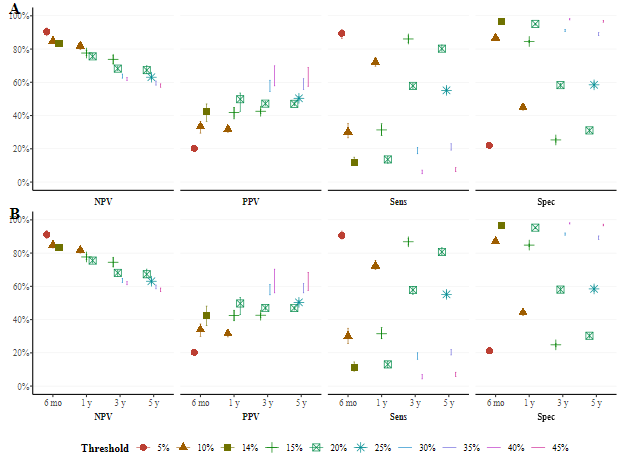

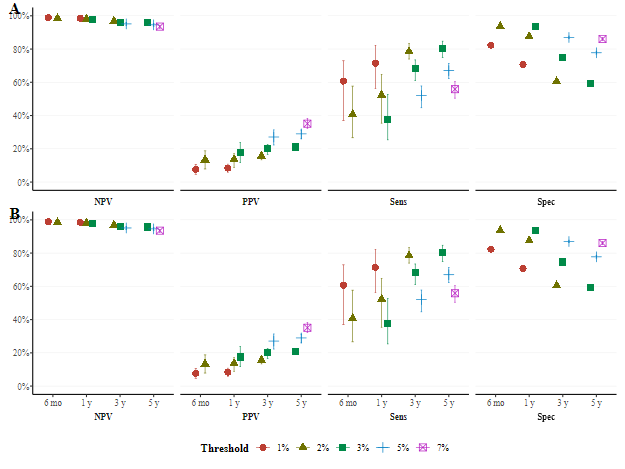

In [44]:
#| label: threshold-metrics-plot
#| message: false
#| fig-width: 10
#| fig-height: 5

source(file.path(project_root, "cons/_hist_scripts/plot_threshold_metrics_from_summary_long.R"))

# panel_models MUST match the labels passed to run_threshold_metrics_*.
# Points = mean across CV replicates; bars = empirical 2.5th-97.5th percentiles
# (split-to-split spread, NOT confidence intervals).
figs_thr_metrics <- plot_threshold_metrics_separate_outcomes(
  summary_long = threshold_out_best2$summary_long,
  horizons     = c(6, 12, 36, 60),
  panel_models = c("Full PH updated2", "SHAP primary"),
  panel_titles = c("Full PH", "SHAP primary"),
  metrics      = c("NPV", "PPV", "Sens", "Spec"),
  save_files   = FALSE
)

# Render both figures
print(figs_thr_metrics$outcomes$Readmission$plot)
print(figs_thr_metrics$outcomes$Death$plot)


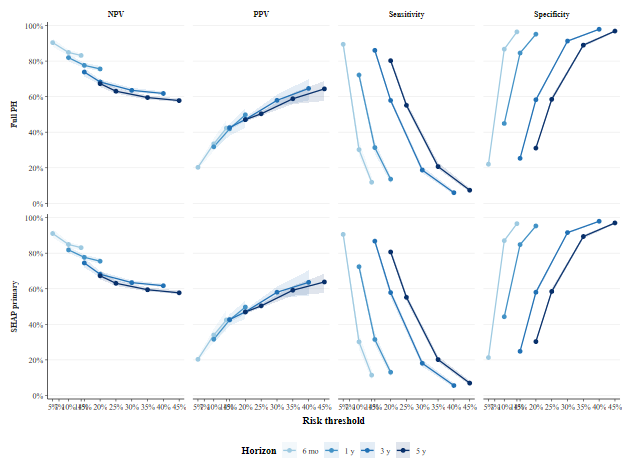

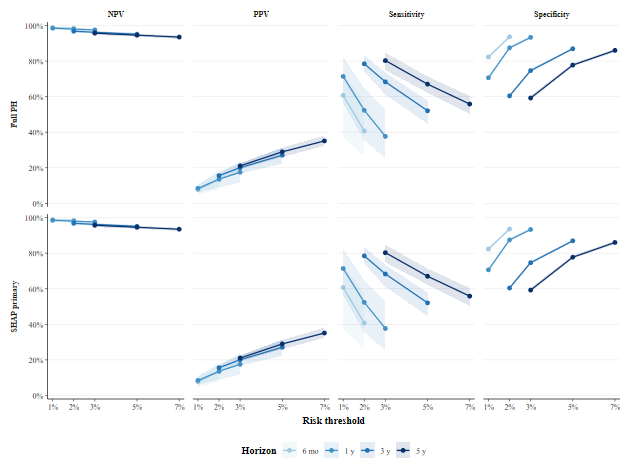

In [45]:
#| label: threshold-metrics-epidemiology-corrected
#| results: hold
source(file.path(project_root, "cons/_alt_scripts/plot_threshold_metrics_clean.R"))

figs_thr_metrics <- plot_threshold_metrics_clean(
  summary_long = threshold_out_best2$summary_long,
  horizons     = c(6, 12, 36, 60),
  panel_models = c("Full PH updated2", "SHAP primary"),
  panel_titles = c("Full PH", "SHAP primary"),
  metrics      = c("NPV", "PPV", "Sens", "Spec"),
  uncertainty  = "ribbon",   # "errorbar" o "none" si lo quieres aún más limpio
  save_files   = FALSE
)

print(figs_thr_metrics$outcomes$Readmission$plot)
print(figs_thr_metrics$outcomes$Death$plot)


In [46]:
#| label: threshold-metrics-epidemiology2
#| results: hold

# ── Threshold metrics: best_perf vs best_perf2 ────────────────────────────────
threshold_out_bestperf12 <- run_threshold_metrics_from_results_boot(
  results_boot_reference = results_shap_xgb_py_upd_best_perf,   # best_perf
  results_boot_updated   = results_shap_xgb_py_upd_best_perf2,  # best_perf2
  threshold_spec  = threshold_spec,        # mismo spec de la celda anterior
  reference_label = "SHAP primary",        # best_perf
  updated_label   = "SHAP implemented",    # best_perf2
  estimator       = "ipcw",                # competing-risk readmission; admin-IPCW death
  output_dir = file.path(project_root, "cons", "_out", "threshold_metrics_bestperf12"),
  prefix     = "threshold_metrics_bestperf12"
)
cat(sprintf("Readmission competing-risk reps=%d | fallback=%d\n",
            threshold_out_bestperf12$config$n_readmit_competing_risk,
            threshold_out_bestperf12$config$n_readmit_ipcw_fallback))


Threshold metrics: IPCW. Readmission competing-risk on 50 replicate(s). Death: admin-censoring IPCW.
Readmission competing-risk reps=50 | fallback=0


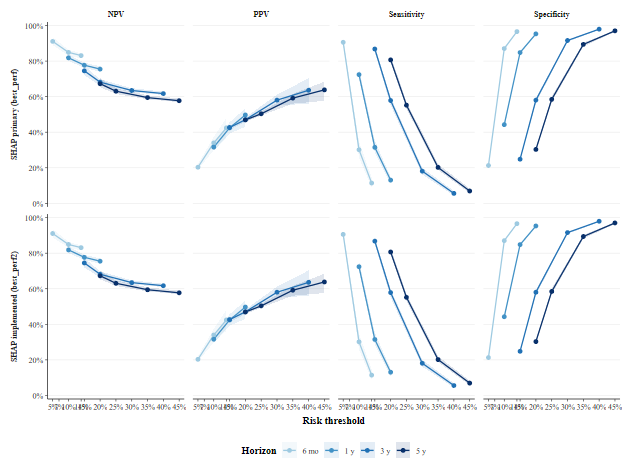

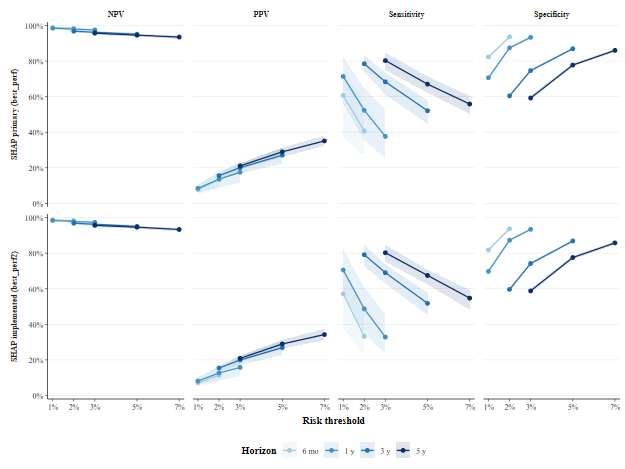

In [47]:
#| label: threshold-metrics-epidemiology3
#| results: hold

figs_bestperf12 <- plot_threshold_metrics_clean(
  summary_long = threshold_out_bestperf12$summary_long,
  horizons     = c(6, 12, 36, 60),
  panel_models = c("SHAP primary", "SHAP implemented"),
  panel_titles = c("SHAP primary (best_perf)", "SHAP implemented (best_perf2)"),
  metrics      = c("NPV", "PPV", "Sens", "Spec"),
  uncertainty  = "ribbon",
  save_files   = FALSE
)
print(figs_bestperf12$outcomes$Readmission$plot)
print(figs_bestperf12$outcomes$Death$plot)


In [48]:
#| label: threshold-metrics-epidemiology4-save
#| results: hold
source(file.path(project_root, "cons/_alt_scripts/save_threshold_metric_figures.R"))

out_fig <- file.path(project_root, "cons", "_figs")

# Figura principal (Full PH vs SHAP primary)
save_threshold_metric_figures(
  figs_thr_metrics, output_dir = out_fig,
  prefix  = "threshold_clean_primary",
  formats = c("png", "pdf", "tiff"))

# Figura best_perf vs best_perf2
save_threshold_metric_figures(
  figs_bestperf12, output_dir = out_fig,
  prefix  = "threshold_clean_bestperf12",
  formats = c("png", "pdf", "tiff"))


Saved 6 file(s) to G:/My Drive/Alvacast/SISTRAT 2023/cons/_figs


There were 25 warnings (use warnings() to see them)


Saved 6 file(s) to G:/My Drive/Alvacast/SISTRAT 2023/cons/_figs


There were 24 warnings (use warnings() to see them)


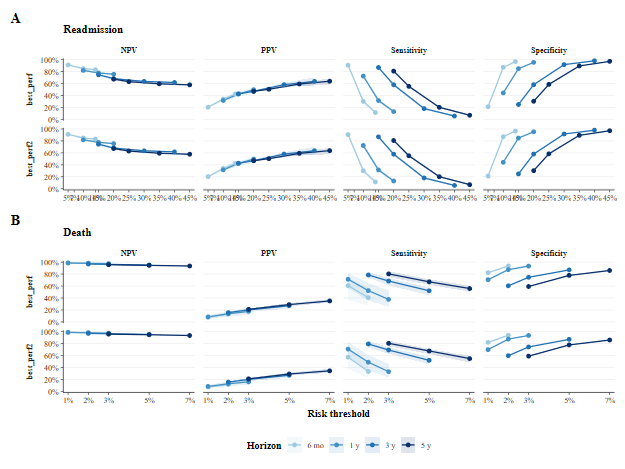

In [49]:
#| label: threshold-metrics-epidemiology5-combined
#| results: hold
source(file.path(project_root, "cons/_alt_scripts/plot_threshold_metrics_clean.R"))
source(file.path(project_root, "cons/_alt_scripts/plot_threshold_metrics_clean_combined.R"))

fig_comb_bp12 <- plot_threshold_metrics_clean_combined(
  summary_long = threshold_out_bestperf12$summary_long,
  horizons     = c(6, 12, 36, 60),
  panel_models = c("SHAP primary", "SHAP implemented"),  # debe calzar con summary_long
  panel_titles = c("best_perf", "best_perf2"),           # rótulo de fila (libre)
  metrics      = c("NPV", "PPV", "Sens", "Spec"),
  uncertainty  = "ribbon"
)
print(fig_comb_bp12$plot)


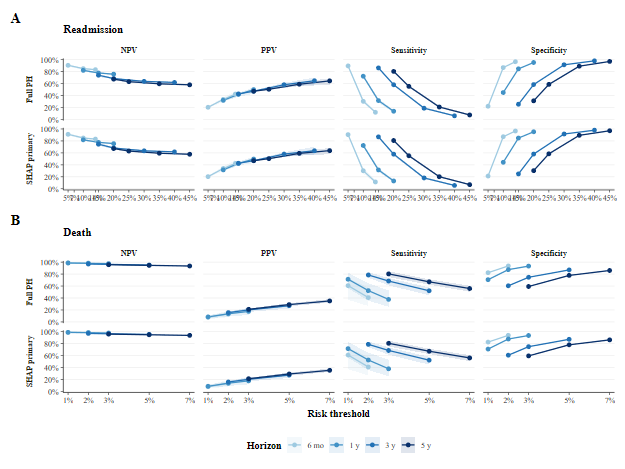

In [50]:
#| label: threshold-metrics-epidemiology5-plot2
#| results: hold
fig_comb_primary <- plot_threshold_metrics_clean_combined(
  summary_long = threshold_out_best2$summary_long,
  panel_models = c("Full PH updated2", "SHAP primary"),
  panel_titles = c("Full PH", "SHAP primary"),
  uncertainty  = "ribbon"
)
print(fig_comb_primary$plot)


In [51]:
#| label: threshold-metrics-epidemiology6-save-combined
#| results: hold
out_fig <- file.path(project_root, "cons", "_figs")

save_threshold_metric_figures(
  fig_comb_bp12, output_dir = out_fig,
  prefix    = "threshold_clean_bestperf12_combined",
  height_cm = 20, width_cm = 19,
  formats   = c("png", "pdf", "tiff"))

save_threshold_metric_figures(
  fig_comb_primary, output_dir = out_fig,
  prefix    = "threshold_clean_fullph_shap_combined",
  height_cm = 20, width_cm = 19,
  formats   = c("png", "pdf", "tiff"))

Saved 3 file(s) to G:/My Drive/Alvacast/SISTRAT 2023/cons/_figs


There were 33 warnings (use warnings() to see them)


Saved 3 file(s) to G:/My Drive/Alvacast/SISTRAT 2023/cons/_figs


There were 29 warnings (use warnings() to see them)


In [52]:
#| label: threshold-metrics-table-html
#| message: false
#| results: asis

library(htmltools)

thr_tbl <- threshold_out_best2$summary_wide  # one row per Model x Risk x Time x Threshold

utils::write.csv(
  thr_tbl,
  file.path(project_root, "cons", "_out", "table_threshold_metrics_best2.csv"),
  row.names = FALSE
)

htmltools::browsable(htmltools::tags$div(
  style = "max-height:550px; overflow:auto; border:1px solid #ddd; font-family:Arial, sans-serif; font-size:12px;",
  htmltools::tags$table(
    style = "border-collapse:collapse; width:max-content; min-width:100%;",
    htmltools::tags$thead(htmltools::tags$tr(lapply(names(thr_tbl), function(nm)
      htmltools::tags$th(style = "position:sticky; top:0; background:#f3f3f3; border-bottom:1px solid #ccc; padding:4px 8px; text-align:left; white-space:nowrap;", nm)))),
    htmltools::tags$tbody(lapply(seq_len(nrow(thr_tbl)), function(i)
      htmltools::tags$tr(lapply(thr_tbl[i, ], function(x)
        htmltools::tags$td(style = "border-bottom:1px solid #eee; padding:3px 8px; white-space:nowrap;", as.character(x))))))
  )
))

Model,Risk,Time,Threshold,n_replicates,mean_valid_n,mean_cases_n,mean_controls_n,mean_pred_positive_n,NPV,PPV,Sens,Spec,F1
Full PH updated2,Death,6,0.01,25,12911.6,92.6,12819,2574.96,0.988 (0.981 to 0.993),0.077 (0.047 to 0.107),0.607 (0.370 to 0.729),0.823 (0.813 to 0.834),0.136 (0.085 to 0.184)
Full PH updated2,Death,6,0.02,25,12911.6,92.6,12819,952.48,0.985 (0.978 to 0.990),0.134 (0.079 to 0.187),0.407 (0.266 to 0.577),0.936 (0.931 to 0.945),0.200 (0.125 to 0.279)
Full PH updated2,Death,12,0.01,25,12464.6,141.2,12323.4,4251.72,0.985 (0.977 to 0.990),0.084 (0.059 to 0.108),0.714 (0.563 to 0.823),0.706 (0.695 to 0.715),0.151 (0.107 to 0.190)
Full PH updated2,Death,12,0.02,25,12464.6,141.2,12323.4,1868.12,0.980 (0.971 to 0.985),0.136 (0.089 to 0.171),0.523 (0.354 to 0.648),0.875 (0.867 to 0.884),0.216 (0.145 to 0.268)
Full PH updated2,Death,12,0.03,25,12464.6,141.2,12323.4,1012.2,0.975 (0.967 to 0.982),0.175 (0.117 to 0.238),0.377 (0.254 to 0.527),0.933 (0.927 to 0.942),0.238 (0.164 to 0.324)
Full PH updated2,Death,36,0.02,25,9745.8,340,9405.8,5813.48,0.968 (0.961 to 0.976),0.156 (0.134 to 0.173),0.785 (0.740 to 0.833),0.604 (0.594 to 0.616),0.260 (0.227 to 0.284)
Full PH updated2,Death,36,0.03,25,9745.8,340,9405.8,3836.44,0.962 (0.953 to 0.969),0.201 (0.167 to 0.225),0.683 (0.611 to 0.735),0.747 (0.739 to 0.756),0.310 (0.264 to 0.343)
Full PH updated2,Death,36,0.05,25,9745.8,340,9405.8,2078.68,0.951 (0.943 to 0.959),0.271 (0.223 to 0.314),0.521 (0.447 to 0.578),0.870 (0.862 to 0.878),0.356 (0.303 to 0.400)
Full PH updated2,Death,60,0.03,25,6811.2,475.8,6335.4,6274.16,0.957 (0.946 to 0.965),0.211 (0.192 to 0.225),0.803 (0.749 to 0.847),0.592 (0.583 to 0.606),0.333 (0.306 to 0.352)
Full PH updated2,Death,60,0.05,25,6811.2,475.8,6335.4,3720.68,0.946 (0.937 to 0.954),0.290 (0.260 to 0.313),0.670 (0.623 to 0.713),0.778 (0.770 to 0.787),0.404 (0.368 to 0.428)


**Setup**
- Thresholds anchored to each horizon's event rate (0.5x–2x); metrics are 5×5 CV means with competing-risk IPCW (readmission) / administrative IPCW (mortality).

**Mortality — a rule-out tool**

- High NPV (0.94–0.99), low PPV (0.08–0.35); PPV capped by the rare outcome (0.7%–4.5%).
- Example (60 months, 5% threshold): Sens 0.67 · Spec 0.78 · PPV 0.29 · NPV 0.95.
- Best for prioritizing surveillance, not for triggering definitive action.

**Readmission — balanced**
- PPV up to 0.65; F1 peaks near the threshold = event rate.
- Example (60 months, 20% threshold): Sens 0.80 · Spec 0.31 · PPV 0.47 · F1 0.59.
- Usable for both ruling in and ruling out at moderate thresholds.

**Cross-cutting**
- No single optimal threshold — the cut point depends on the cost of the clinical action; net benefit (DCA) integrates these components.
- Full PH and SHAP operating points are equivalent (identical for mortality) → keep Full PH primary; SHAP as sensitivity.

---

## 8. Delta IBS /Uno's C

In [53]:
#| label: deltaCIBS-cv-fit-commongrid
GRID <- c(3, 6, 12, 36, 60)
specs <- list(  # cada uno = (readmit, death); editá a tus grupos
  base     = list(formula_readmit, formula_death),
  updated  = list(formula_readmit_updated, formula_death_updated),
  updated2 = list(formula_readmit_updated2, formula_death_updated2),
  shap     = list(formula_shap_readmit_clean_updated, formula_shap_death_rule2),
  interact = list(formula_shap_readmit_interact, formula_shap_death_interact)
)
clean_strata <- function(f) stats::as.formula(gsub("strat\\(","strata(",paste(deparse(f),collapse=" ")))
dual_fits <- list()
for (nm in names(specs)) {
  fr <- specs[[nm]][[1]]; fd <- specs[[nm]][[2]]
  if (is.null(fr) || is.null(fd)) { message("skip ", nm); next }
  cat("dual:", nm, "\n"); flush.console()
  dual_fits[[nm]] <- evaluate_dual_cox_python_style(
    formula_readmit = clean_strata(fr), formula_death = clean_strata(fd),
    imputed_list = py_corrected_datasets_boot, k_folds = 5, eval_times = GRID)
}


dual: base 
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
dual: updated 
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
dual: updated2 
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
dual: shap 
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
dual: interact 
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


In [54]:
#| label: deltaCIBS-cv-run

# C-index variant is fixed BY CONSTRUCTION: .dual_cox_safe_concordance (lp marker, ymax=NULL=global,
# no strata arg => within_strata=FALSE). dualcox.* options do NOT affect this bootstrap; they only
# change the engine's $summary. raw_predictions$lp_val is the model linear predictor (option-invariant).
options(dualcox.concordance_score = "lp", dualcox.concordance_within_strata = FALSE)  # doc/guard only
stopifnot(identical(names(formals(.dual_cox_safe_concordance)), c("time","event","lp","ymax")))

B_DELTA <- 500L   # bootstrap reps per paired delta (lower for a quick sweep, raise for the final report)

# Consume the CONSISTENT dual_fits built by 'deltaCIBS-cv-fit-commongrid'
# (all on py_corrected_datasets_boot, k_folds=5, eval_times=GRID) -> ΔC and ΔIBS both comparable.
stopifnot(exists("dual_fits"), exists("specs"))
dual_fits <- dual_fits[!vapply(dual_fits, is.null, logical(1))]
# Keep only objects that still carry raw_predictions (NOT stripped/calibration objects)
ok_raw <- vapply(dual_fits, function(f) !is.null(f$raw_predictions), logical(1))
if (any(!ok_raw)) cat("Dropped (no raw_predictions):", paste(names(dual_fits)[!ok_raw], collapse = ", "), "\n")
dual_fits <- dual_fits[ok_raw]
stopifnot(length(dual_fits) >= 2)
cat("Models:", paste(names(dual_fits), collapse = ", "), "\n")

# Guard: ΔIBS is only comparable if every object shares the same eval_times grid
ets <- vapply(dual_fits, function(f) paste(f$config$eval_times, collapse = ","), "")
if (length(unique(ets)) > 1) warning("Different eval_times across objects -> dIBS NOT comparable")

# Cache .cv_extract once per (model, outcome)
EX <- new.env()
getx <- function(nm, oc) { k <- paste(nm, oc); if (is.null(EX[[k]])) EX[[k]] <- .cv_extract(dual_fits[[nm]], oc); EX[[k]] }

# Per-outcome formula text (from specs) -> skip pairs that share the SAME formula (dC == 0 by definition)
fml_txt <- function(nm, oc) { i <- if (oc == "readmission") 1L else 2L; paste(deparse(specs[[nm]][[i]]), collapse = " ") }

# Fixed rank so A = simpler/earlier model, B = more complex
rank_lvl <- c(base = 1, updated = 2, updated2 = 3, shap = 4, interact = 5, int_corr = 6)
rk <- function(nm) { r <- rank_lvl[nm]; if (is.na(r)) 99L else as.integer(r) }

# Build ALL within-outcome pairwise comparisons (skip identical-formula pairs)
mods <- names(dual_fits)
build_pairs <- function(oc_label) {
  oc <- tolower(oc_label); out <- list(); skipped <- character(0)
  for (p in utils::combn(mods, 2, simplify = FALSE)) {
    p <- p[order(vapply(p, rk, 1L))]                                   # A = simpler, B = more complex
    if (identical(fml_txt(p[1], oc), fml_txt(p[2], oc))) { skipped <- c(skipped, sprintf("%s~%s", p[1], p[2])); next }
    out[[length(out) + 1L]] <- c(p[1], p[2], oc_label)
  }
  if (length(skipped)) cat(sprintf("[%s] skipped identical formula: %s\n", oc_label, paste(skipped, collapse = ", ")))
  out
}
cmp <- c(build_pairs("Readmission"), build_pairs("Death"))
cat(sprintf("Running %d comparisons x 2 metrics x B=%d ...\n", length(cmp), B_DELTA)); flush.console()

t0 <- Sys.time()
delta_tbl <- do.call(rbind, lapply(seq_along(cmp), function(i) {
  z <- cmp[[i]]; oc <- tolower(z[3]); A <- getx(z[1], oc); Z <- getx(z[2], oc)
  dc <- deltaC_boot_x(A, Z, B = B_DELTA); di <- deltaIBS_boot_x(A, Z, B = B_DELTA)
  cat(sprintf("  [%d/%d] %s: %s vs %s  (%.1fs)\n", i, length(cmp), z[3], z[1], z[2],
              as.numeric(difftime(Sys.time(), t0, units = "secs")))); flush.console()
  data.frame(
    outcome = z[3], A = z[1], B = z[2],
    C_A = dc$C_A, C_B = dc$C_B, dC = dc$dC,
    dC_CI = sprintf("[%.4f, %.4f]", dc$dC_lo, dc$dC_hi),
    dC_favors = ifelse(dc$excludes_0, ifelse(dc$dC > 0, z[1], z[2]), "ns"),
    IBS_A = di$IBS_A, IBS_B = di$IBS_B, dIBS = di$dIBS,
    dIBS_CI = sprintf("[%.4f, %.4f]", di$dIBS_lo, di$dIBS_hi),
    dIBS_favors = ifelse(di$excludes_0, ifelse(di$dIBS < 0, z[1], z[2]), "ns"),  # lower IBS is better
    n = dc$n, stringsAsFactors = FALSE)
}))
delta_tbl <- delta_tbl[order(delta_tbl$outcome, -abs(delta_tbl$dC)), ]; rownames(delta_tbl) <- NULL
knitr::kable(delta_tbl, "markdown",
  caption = sprintf("CV-OOF development: paired dC (Uno, lp/global) & dIBS (IPCW), B=%d. dC=C_A-C_B (>0 favors A); dIBS=IBS_A-IBS_B (<0 favors A); '*_favors'=ns when 95%% CI includes 0.", B_DELTA))


Models: base, updated, updated2, shap, interact 
Running 20 comparisons x 2 metrics x B=500 ...
  [1/20] Readmission: base vs updated  (169.1s)
  [2/20] Readmission: base vs updated2  (339.9s)
  [3/20] Readmission: base vs shap  (516.4s)
  [4/20] Readmission: base vs interact  (700.0s)
  [5/20] Readmission: updated vs updated2  (889.8s)
  [6/20] Readmission: updated vs shap  (1085.0s)
  [7/20] Readmission: updated vs interact  (1291.7s)
  [8/20] Readmission: updated2 vs shap  (1524.1s)
  [9/20] Readmission: updated2 vs interact  (1776.5s)
  [10/20] Readmission: shap vs interact  (2039.0s)
  [11/20] Death: base vs updated  (2280.7s)
  [12/20] Death: base vs updated2  (2505.1s)
  [13/20] Death: base vs shap  (2734.6s)
  [14/20] Death: base vs interact  (2981.2s)
  [15/20] Death: updated vs updated2  (3238.1s)
  [16/20] Death: updated vs shap  (3506.4s)
  [17/20] Death: updated vs interact  (3811.5s)
  [18/20] Death: updated2 vs shap  (4090.1s)
  [19/20] Death: updated2 vs interact  (4396



Table: CV-OOF development: paired dC (Uno, lp/global) & dIBS (IPCW), B=500. dC=C_A-C_B (>0 favors A); dIBS=IBS_A-IBS_B (<0 favors A); '*_favors'=ns when 95% CI includes 0.

|outcome     |A        |B        |    C_A|    C_B|      dC|dC_CI              |dC_favors |  IBS_A|  IBS_B|   dIBS|dIBS_CI            |dIBS_favors |     n|
|:-----------|:--------|:--------|------:|------:|-------:|:------------------|:---------|------:|------:|------:|:------------------|:-----------|-----:|
|Death       |updated  |shap     | 0.7431| 0.7403|  0.0028|[-0.0016, 0.0077]  |ns        | 0.0674| 0.0680| -6e-04|[-0.0009, -0.0004] |updated     | 70521|
|Death       |updated2 |shap     | 0.7431| 0.7403|  0.0028|[-0.0016, 0.0077]  |ns        | 0.0674| 0.0680| -6e-04|[-0.0009, -0.0004] |updated2    | 70521|
|Death       |base     |shap     | 0.7429| 0.7403|  0.0026|[-0.0018, 0.0076]  |ns        | 0.0674| 0.0680| -6e-04|[-0.0009, -0.0004] |base        | 70521|
|Death       |updated  |interact | 0.7431| 0.7417|

~ 106 minutes

---
## 9. Save environment for later use

In [55]:
#| label: save-results
#| message: false

gc()

out_dir  <- file.path(project_root, "data", "20241015_out")
out_stem <- sprintf("pred225_metrics_%s", format(Sys.Date(), "%Y_%m_%d"))

# ── Strip individual-level data before saving ─────────────────────────────────
# Handles a single result object (has $raw_predictions directly) OR
# a named list of result objects (each element may have $raw_predictions).
.strip_raw <- function(obj) {
  if (!is.list(obj)) return(obj)
  if ("raw_predictions" %in% names(obj)) {        # single result object
    obj$raw_predictions <- NULL
    return(obj)
  }
  lapply(obj, function(m) {                        # named list of results
    if (is.list(m) && "raw_predictions" %in% names(m)) m$raw_predictions <- NULL
    m
  })
}
# ── Formulas — pred21/22 always saved these; small, no patient data ───────────
formula_names_all <- c(
  "formula_readmit",               "formula_readmit_updated",    "formula_readmit_updated2",
  "formula_death",                 "formula_death_updated",      "formula_death_updated2",
  "formula_shap_readmit_clean",    "formula_shap_readmit_clean_updated",
  "formula_shap_readmit_interact",
  "formula_shap_death",            "formula_shap_death_interact", 
  "formula_shap_ds_readmit_clean_updated", "formula_shap_ds_readmit_interact",
  "formula_shap_ds_death_updated", "formula_shap_ds_death_interact"
)
formulas_agg <- Filter(Negate(is.null),
  setNames(
    lapply(formula_names_all, function(fn) if (exists(fn)) get(fn) else NULL),
    formula_names_all
  )
)
# ── Primary eval results loaded from pred22 — strip raw_predictions ───────────
# These were saved by save.image() in pred22 and contain individual patient data.
# results_upd2_py               = Full PH updated2 (readmit + death)
# results_shap_xgb_py_upd_best_perf   = SHAP clean (primary model)
# results_shap_xgb_py_upd_best_perf3  = SHAP readmit + interact
# results_shap_xgb_py_upd_best_perf2 = implementation combo:
# formula_shap_readmit_clean_updated + formula_shap_death
pred22_results_agg <- Filter(Negate(is.null), list(
  results_upd2_py = if (exists("results_upd2_py"))
    .strip_raw(results_upd2_py) else NULL,
  results_shap_xgb_py_upd_best_perf = if (exists("results_shap_xgb_py_upd_best_perf"))
    .strip_raw(results_shap_xgb_py_upd_best_perf) else NULL,
  results_shap_xgb_py_upd_best_perf2 = if (exists("results_shap_xgb_py_upd_best_perf2"))
    .strip_raw(results_shap_xgb_py_upd_best_perf2) else NULL,
  results_shap_xgb_py_upd_best_perf3 = if (exists("results_shap_xgb_py_upd_best_perf3"))
    .strip_raw(results_shap_xgb_py_upd_best_perf3) else NULL
))
# ── DCA bundle ────────────────────────────────────────────────────────────────
dca_agg <- Filter(Negate(is.null), list(
  models_full    = if (exists("dca_models_full"))          dca_models_full          else NULL,
  nb_full_ph     = if (exists("dca_nb_full_ph"))           dca_nb_full_ph           else NULL,
  nb_shap_clean  = if (exists("dca_nb_shap_clean"))        dca_nb_shap_clean        else NULL,
  nb_implemented = if (exists("dca_nb_shap_implemented"))  dca_nb_shap_implemented  else NULL,
  dca_readmit    = if (exists("dca_readmit"))              dca_readmit              else NULL,
  dca_death      = if (exists("dca_death"))                dca_death                else NULL
))
if (length(dca_agg) == 0L) dca_agg <- NULL
# NRI/IDI and threshold metrics - compact, no raw replicate payload
.nri_idi_compact <- function(x) {
  if (!is.list(x)) return(x)
  Filter(Negate(is.null), list(
    summary = x$summary,
    config  = x$config
  ))
}
.threshold_compact <- function(x) {
  if (!is.list(x)) return(x)
  Filter(Negate(is.null), list(
    summary_long = x$summary_long,
    summary_wide = x$summary_wide,
    thresholds   = x$thresholds,
    config       = x$config
  ))
}
.get_if_exists <- function(nm) {
  if (exists(nm, inherits = TRUE)) get(nm, inherits = TRUE) else NULL
}
nri_idi_object_names <- c(
  best2    = "nri_idi_best2",
  best2vs1 = "nri_idi_best2vs1"
)
nri_idi_agg <- Filter(Negate(is.null),
  lapply(nri_idi_object_names, function(nm) {
    x <- .get_if_exists(nm)
    if (is.null(x)) NULL else .nri_idi_compact(x)
  })
)
nri_idi_table_names <- c(
  best2    = "nri_idi_model_table",
  best2vs1 = "nri_idi_model_table2"
)
nri_idi_tables_agg <- Filter(Negate(is.null),
  lapply(nri_idi_table_names, .get_if_exists)
)
# ── Bundle all aggregate results ──────────────────────────────────────────────
results_agg <- Filter(Negate(is.null), list(
  # Model definitions (needed to reproduce any fit)
  formulas           = if (length(formulas_agg) > 0L) formulas_agg else NULL,
  # Primary pred22 eval results, stripped (same coverage as pred22 save.image but safe)
  pred22_results     = if (length(pred22_results_agg) > 0L) pred22_results_agg else NULL,
  # Calibration: readmission (pooled_summary, rep_results, flat, calibration_curves)
  cal_readmit        = if (exists("cal_results"))       cal_results       else NULL,
  # Calibration: death
  cal_death_flat     = if (exists("death_cal_results")) death_cal_results else NULL,
  cal_death_full     = if (exists("death_cal_full"))    death_cal_full    else NULL,
  # Dual metrics from this notebook (strip raw_predictions)
  dual_pending       = if (exists("dual_pending_results")) .strip_raw(dual_pending_results) else NULL,
  ds_dual            = if (exists("ds_dual_results"))      .strip_raw(ds_dual_results)      else NULL,
  # Add to results_agg bundle (after cal_death_full):
  cal_readmit_ds     = if (exists("cal_results_ds"))        cal_results_ds        else NULL,
  cal_death_ds_flat  = if (exists("death_cal_results_ds"))  death_cal_results_ds  else NULL,
  cal_death_ds_full  = if (exists("death_cal_full_ds"))     death_cal_full_ds     else NULL,
  # DCA (aggregate net-benefit tables only)
  dca                = dca_agg,
  # Summary tables
  ici_readmit_table  = if (exists("ici_readmit_table"))   ici_readmit_table   else NULL,
  ici_death_table    = if (exists("ici_death_table"))     ici_death_table     else NULL,
  consolidated_table = if (exists("consolidated_table"))  consolidated_table  else NULL,
  # Article-2 authoritative selection objects (section 8)
  model_registry        = if (exists("model_registry"))        model_registry        else NULL,
  supp_model_comparison = if (exists("supp_model_comparison")) supp_model_comparison else NULL,
  nri_idi        = if (length(nri_idi_agg) > 0L) nri_idi_agg else NULL,
  nri_idi_tables = if (length(nri_idi_tables_agg) > 0L) nri_idi_tables_agg else NULL,
  threshold_metrics  = if (exists("threshold_out_best2")) .threshold_compact(threshold_out_best2) else NULL,
  threshold_table    = if (exists("thr_tbl")) thr_tbl else NULL
))

# ── RDS: single named list, no namespace pollution on load ────────────────────
rds_path <- file.path(out_dir, paste0(out_stem, ".rds"))
saveRDS(results_agg, rds_path)
cat("Saved RDS:", rds_path, "\n")

# ── CSV exports for flat tables ───────────────────────────────────────────────
csv_dir <- file.path(project_root, "cons", "_out")
if (!dir.exists(csv_dir)) dir.create(csv_dir, recursive = TRUE)

csv_exports <- Filter(Negate(is.null), list(
  ici_readmit_multihorizonte = if (exists("ici_readmit_table"))   ici_readmit_table   else NULL,
  ici_death_multihorizonte   = if (exists("ici_death_table"))     ici_death_table     else NULL,
  tabla_consolidada_dual     = if (exists("consolidated_table"))  consolidated_table  else NULL,
  nri_idi_best2              = if (exists("nri_idi_model_table"))  nri_idi_model_table  else NULL,
  nri_idi_best2vs1           = if (exists("nri_idi_model_table2")) nri_idi_model_table2 else NULL,
  threshold_metrics_best2    = if (exists("thr_tbl")) thr_tbl else NULL
))
for (nm in names(csv_exports)) {
  p <- file.path(csv_dir, paste0(nm, ".csv"))
  utils::write.csv(csv_exports[[nm]], p, row.names = FALSE)
  cat("  CSV:", basename(p), "\n")
}

# ── Summary ───────────────────────────────────────────────────────────────────
cat("\nObjects in RDS:\n")
for (nm in names(results_agg)) cat(sprintf("  - %s\n", nm))
cat(sprintf("\n  formulas saved: %d | pred22 results stripped: %d\n",
            length(results_agg$formulas), length(results_agg$pred22_results)))
cat("NOT saved: py_corrected_datasets* (individual patient data)\n")
cat("NOT saved: raw_predictions in any evaluate_dual_cox result\n")
cat("Load with: results_agg <- readRDS('", basename(rds_path), "')\n", sep = "")

Saved RDS: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/pred225_metrics_2026_06_19.rds 
  CSV: ici_readmit_multihorizonte.csv 
  CSV: ici_death_multihorizonte.csv 
  CSV: tabla_consolidada_dual.csv 
  CSV: nri_idi_best2.csv 
  CSV: nri_idi_best2vs1.csv 
  CSV: threshold_metrics_best2.csv 

Objects in RDS:
  - formulas
  - pred22_results
  - cal_readmit
  - cal_death_flat
  - cal_death_full
  - dual_pending
  - dca
  - ici_readmit_table
  - ici_death_table
  - consolidated_table
  - nri_idi
  - nri_idi_tables
  - threshold_metrics
  - threshold_table

  formulas saved: 11 | pred22 results stripped: 3
NOT saved: py_corrected_datasets* (individual patient data)
NOT saved: raw_predictions in any evaluate_dual_cox result
Load with: results_agg <- readRDS('pred225_metrics_2026_06_19.rds')


In [56]:
gc()

             used    (Mb) gc trigger    (Mb)   max used    (Mb)
Ncells   11814669   631.0   17535522   936.5   17535522   936.5
Vcells 2774065151 21164.5 4153951029 31692.2 4153950707 31692.2

In [57]:
#| label: save-plot-objects-individual-rds
#| message: false

# Output folder for individual plot RDS files
plot_rds_dir <- file.path(project_root, "data", "20241015_out", "plot_objects")
if (!dir.exists(plot_rds_dir)) dir.create(plot_rds_dir, recursive = TRUE)

# Date prefix: YYYY_MM_DD_
date_prefix <- format(Sys.Date(), "%Y_%m_%d_")

# Helper: save only if the object is not NULL
.save_plot_rds <- function(obj, fname) {
  if (is.null(obj)) return(invisible(NULL))
  path <- file.path(plot_rds_dir, fname)
  saveRDS(obj, path)
  cat("  saved:", fname, "\n")
  invisible(path)
}

# Collect all plot objects
plot_objects <- list()

# 1. Calibration panels
plot_objects$readmission_calibration_combined_AB <- if (exists("final_readmit")) final_readmit else NULL
plot_objects$mortality_calibration_combined_AB   <- if (exists("final_death"))   final_death   else NULL

# 2. DCA panels
plot_objects$dca_readmit_fullph_vs_shap_clean     <- if (exists("p_readmit_panel")) p_readmit_panel else NULL
plot_objects$dca_death_fullph_vs_shap_implemented <- if (exists("p_death_panel"))   p_death_panel   else NULL

# 3. Threshold-metric plots (primary comparison)
if (exists("figs_thr_metrics") && is.list(figs_thr_metrics)) {
  plot_objects$threshold_metrics_primary_readmit <- figs_thr_metrics$outcomes$Readmission$plot
  plot_objects$threshold_metrics_primary_death   <- figs_thr_metrics$outcomes$Death$plot
}

# 4. Threshold-metric plots (best_perf vs best_perf2)
if (exists("figs_bestperf12") && is.list(figs_bestperf12)) {
  plot_objects$threshold_metrics_bestperf12_readmit <- figs_bestperf12$outcomes$Readmission$plot
  plot_objects$threshold_metrics_bestperf12_death   <- figs_bestperf12$outcomes$Death$plot
}

# 5. Combined threshold-metric plots
plot_objects$threshold_metrics_bestperf12_combined <- if (exists("fig_comb_bp12") && is.list(fig_comb_bp12)) fig_comb_bp12$plot else NULL
plot_objects$threshold_metrics_primary_combined    <- if (exists("fig_comb_primary") && is.list(fig_comb_primary)) fig_comb_primary$plot else NULL

# Save each plot object as its own dated RDS file
cat("Saving individual plot objects to:", plot_rds_dir, "\n")
for (nm in names(plot_objects)) {
  .save_plot_rds(plot_objects[[nm]], paste0(date_prefix, nm, ".rds"))
}

# Optional manifest
manifest <- data.frame(
  object_name = names(plot_objects),
  file = file.path(plot_rds_dir, paste0(date_prefix, names(plot_objects), ".rds")),
  stringsAsFactors = FALSE
)
write.csv(manifest, file.path(plot_rds_dir, paste0(date_prefix, "plot_objects_manifest.csv")), row.names = FALSE)
cat("Manifest saved.\n")

Saving individual plot objects to: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/plot_objects 
  saved: 2026_06_19_readmission_calibration_combined_AB.rds 
  saved: 2026_06_19_mortality_calibration_combined_AB.rds 
  saved: 2026_06_19_dca_readmit_fullph_vs_shap_clean.rds 
  saved: 2026_06_19_dca_death_fullph_vs_shap_implemented.rds 
  saved: 2026_06_19_threshold_metrics_primary_readmit.rds 
  saved: 2026_06_19_threshold_metrics_primary_death.rds 
  saved: 2026_06_19_threshold_metrics_bestperf12_readmit.rds 
  saved: 2026_06_19_threshold_metrics_bestperf12_death.rds 
  saved: 2026_06_19_threshold_metrics_bestperf12_combined.rds 
  saved: 2026_06_19_threshold_metrics_primary_combined.rds 
Manifest saved.


Save the main database with which we made the 80/20 split

In [58]:
#| label: save-corrected-datasets-original
saveRDS(
  object = corrected_datasets_nondum_filt,
  file   = file.path("data", "20241015_out", "corrected_datasets_nondum_filt.rds")
)

In [59]:
#| label: session-info
#| echo: true
#| error: true
#| message: true
#| paged.print: true
message(paste0("R library: ", Sys.getenv("R_LIBS_USER")))
message(paste0("Date: ",withr::with_locale(new = c('LC_TIME' = 'C'), code =Sys.time())))
message(paste0("Editor context: ", path))
cat("quarto version: "); quarto::quarto_version()
sesion_info <- devtools::session_info()

tabla_pkg <- dplyr::select(
  tibble::as_tibble(sesion_info$packages),
  package,
  loadedversion,
  source
)

tabla_pkg <- tibble::rowid_to_column(tabla_pkg, var = "row_number")

names(tabla_pkg) <- c("Row number", "Package", "Version", "Source")

htmltools::browsable(
  htmltools::tags$div(
    style = "
      max-height: 420px;
      overflow: auto;
      border: 1px solid #ddd;
      font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
      font-size: 70%;
      line-height: 0.75em;
      width: 100%;
    ",
    htmltools::tags$caption(
      style = "
        caption-side: top;
        text-align: left;
        display: block;
        padding: 6px 4px;
        font-size: 120%;
        line-height: 1.2em;
      ",
      htmltools::em("R packages")
    ),
    htmltools::tags$table(
      style = "
        border-collapse: collapse;
        width: max-content;
        min-width: 100%;
        white-space: nowrap;
      ",
      htmltools::tags$thead(
        htmltools::tags$tr(
          lapply(names(tabla_pkg), function(nm) {
            htmltools::tags$th(
              style = "
                position: sticky;
                top: 0;
                z-index: 2;
                background: #f3f3f3;
                border-bottom: 1px solid #ccc;
                padding: 4px 8px;
                text-align: left;
                white-space: nowrap;
              ",
              nm
            )
          })
        )
      ),
      htmltools::tags$tbody(
        lapply(seq_len(nrow(tabla_pkg)), function(i) {
          htmltools::tags$tr(
            lapply(tabla_pkg[i, ], function(x) {
              htmltools::tags$td(
                style = "
                  border-bottom: 1px solid #eee;
                  padding: 3px 8px;
                  white-space: nowrap;
                ",
                as.character(x)
              )
            })
          )
        })
      )
    ) 
  )
)

R library: G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32
Date: 2026-06-19 08:16:06.605386
Editor context: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/251001_c1_1025_df_prev1y.rds
quarto version: 

Warning message:
In system2("quarto", "-V", stdout = TRUE, env = paste0("TMPDIR=",  :
  running command '"quarto" TMPDIR=C:/Users/andre/AppData/Local/Temp/Rtmp0YWQ7t/file4ed0428233e -V' had status 1


1,abind,1.4-8,RSPM
2,backports,1.5.0,RSPM
3,base64enc,0.1-3,RSPM
4,boot,1.3-30,CRAN (R 4.4.1)
5,broom,1.0.7,RSPM
6,cachem,1.1.0,RSPM
7,car,3.1-3,RSPM
8,carData,3.0-5,RSPM
9,caret,7.0-1,RSPM
10,checkmate,2.3.2,RSPM (R 4.4.0)
11,class,7.3-22,CRAN (R 4.4.1)
